In [13]:
import sys
print(sys.executable)
print(sys.version)
import sys
print(sys.executable)

/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/.venv/bin/python
3.12.12 (main, Oct  9 2025, 11:07:00) [Clang 17.0.0 (clang-1700.6.3.2)]
/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/.venv/bin/python


In [14]:
from obspy.taup.taup_create import build_taup_model

build_taup_model("/Users/ramonmargarit/Desktop/vpremoon_mantle_closed.tvel")

Building obspy.taup model for '/Users/ramonmargarit/Desktop/vpremoon_mantle_closed.tvel' ...
filename = /Users/ramonmargarit/Desktop/vpremoon_mantle_closed.tvel
Done reading velocity model.
Radius of model  is 1737.1
Using parameters provided in TauP_config.ini (or defaults if not) to call SlownessModel...
Parameters are:
taup.create.min_delta_p = 0.1 sec / radian
taup.create.max_delta_p = 11.0 sec / radian
taup.create.max_depth_interval = 115.0 kilometers
taup.create.max_range_interval = 0.04363323129985824 degrees
taup.create.max_interp_error = 0.05 seconds
taup.create.allow_inner_core_s = True
Slow model  985 P layers,937 S layers
Done calculating Tau branches.
Done Saving /Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/.venv/lib/python3.12/site-packages/obspy/taup/data/vpremoon_mantle_closed.npz
Method run is done, but not necessarily successful.


In [15]:
from obspy.taup import TauPyModel

model = TauPyModel(model="vpremoon_mantle_closed")

# arrivals = model.get_ray_paths(
#     source_depth_in_km=200,
#     distance_in_degree=40,
#     phase_list=["P", "S"]
# )
# arrivals.plot_rays(plot_type="spherical", legend=True)

In [16]:
# ============================================================
# Event selection only (no plotting)
# - Load Excel, compute dt_rel vs FC per (station,starttime) event
# - Select events by dt_rel criteria (per scenario)
# - Match Excel events to MiniSEED traces by starttime tolerance
# - Print + SAVE: per scenario list of selected events
#   (time, station, epicentral distance, lat, Lon)
# ============================================================

import os
import numpy as np
import pandas as pd
from obspy import read

# -------------------------
# CONFIG
# -------------------------
xlsx  = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
sheet = "best_7_bands_fixed_hold0"

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"

FC    = 5.0
BANDS = np.array([3., 4., 5., 6., 7., 8., 9.])

STARTTIME_TOL_S = 2.0

SCENARIOS = [
    dict( LOWER_TOL=0.75, MIN_POST=4, K_NEG=0, K_PRE_POS=0),
]

# where to save the selected event lists
OUT_DIR = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/selected_events"
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------------
# EXCEL LOADING / NORMALIZATION
# -------------------------
def _first_existing_col(cols, candidates):
    """Return the first candidate name that exists in cols, else None."""
    for c in candidates:
        if c in cols:
            return c
    return None


def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(
            f"Missing columns in sheet '{sheet}': {missing}\n"
            f"Available: {list(d.columns)}"
        )

    d["station"] = d["station"].astype(str)
    d["fc_hz"]   = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)

    d["starttime_dt"]  = pd.to_datetime(d["starttime"],  errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    # distance
    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    # lat / Lon (support common variants)
    lat_col = _first_existing_col(d.columns, ["lat", "Lat", "LAT", "latitude", "Latitude"])
    lon_col = _first_existing_col(d.columns, ["Lon", "lon", "LON", "longitude", "Longitude"])

    if lat_col is not None:
        d["lat"] = pd.to_numeric(d[lat_col], errors="coerce")
    else:
        d["lat"] = np.nan

    if lon_col is not None:
        d["Lon"] = pd.to_numeric(d[lon_col], errors="coerce")
    else:
        d["Lon"] = np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()

    # Excel notion of event (station + starttime)
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    # dt_rel relative to FC per event (using FC band's t0_dt_mean as reference)
    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "lat", "Lon", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands  = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False)
            continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False)
            continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


# -------------------------
# MATCH MSEED EVENTS TO EXCEL EVENTS
# -------------------------
def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")

        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]

            if ev in event_to_trace:
                prev_tr, prev_diff = event_to_trace[ev]
                if dt.loc[j] < prev_diff:
                    event_to_trace[ev] = (tr, float(dt.loc[j]))
            else:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


# -------------------------
# MAIN
# -------------------------
df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)
dt_mat  = build_event_band_matrix(df_long, BANDS=BANDS)

# event-level distance / lat / Lon (same pattern as epi_deg)
dist_map = (
    df_long[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)
lat_map = (
    df_long[["event", "lat"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["lat"]
    .to_dict()
)
lon_map = (
    df_long[["event", "Lon"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["Lon"]
    .to_dict()
)

# event-level "best time": FC-band t0_dt_mean_dt
t0best_map = (
    df_long[df_long["band"] == FC][["event", "t0_dt_mean_dt"]]
    .dropna()
    .drop_duplicates(subset=["event"])
    .set_index("event")["t0_dt_mean_dt"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

for cfg in SCENARIOS:
    LOWER_TOL = float(cfg["LOWER_TOL"])
    MIN_POST  = int(cfg["MIN_POST"])
    K_NEG     = int(cfg["K_NEG"])
    K_PRE_POS = int(cfg["K_PRE_POS"])

    keep_mask = select_events(
        dt_mat=dt_mat, FC=FC, BANDS=BANDS,
        MIN_POST=MIN_POST, K_NEG=K_NEG, K_PRE_POS=K_PRE_POS,
        LOWER_TOL=LOWER_TOL
    )

    kept_events = keep_mask.index[keep_mask].tolist()
    n_kept, n_tot = int(keep_mask.sum()), int(len(keep_mask))
    print(f" Kept by dt_rel criteria: {n_kept}/{n_tot}")

    # also require a MiniSEED match
    kept_events = [ev for ev in kept_events if ev in event_to_trace]
    print(f"Kept with MiniSEED match: {len(kept_events)}/{n_kept}")

    if not kept_events:
        print(" No events after MiniSEED matching.")
        continue

    # Build table
    rows = []
    for ev in kept_events:
        rows.append(dict(
            event=ev,
            time_utc=t0best_map.get(ev, pd.NaT),
            station=ev.split("__", 1)[-1],
            epi_deg=dist_map.get(ev, np.nan),
            lat=lat_map.get(ev, np.nan),
            Lon=lon_map.get(ev, np.nan),
        ))

    out_df = pd.DataFrame(rows)
    out_df["epi_deg"] = pd.to_numeric(out_df["epi_deg"], errors="coerce")
    out_df["lat"]     = pd.to_numeric(out_df["lat"], errors="coerce")
    out_df["Lon"]     = pd.to_numeric(out_df["Lon"], errors="coerce")

    out_df = out_df.sort_values(["epi_deg", "time_utc"], na_position="last").reset_index(drop=True)

    # Print
    print(
        f"LOWER_TOL={LOWER_TOL}, MIN_POST={MIN_POST}, K_NEG={K_NEG}, K_PRE_POS={K_PRE_POS}\n"
        "Selected events (time_utc, station, epi_deg, lat, Lon):"
    )
    print(out_df.to_string(index=False))

    # Save (CSV)
    tag = f"LOW{LOWER_TOL}_MINPOST{MIN_POST}_KNEG{K_NEG}_KPREPOS{K_PRE_POS}".replace(".", "p")
    out_csv = os.path.join(OUT_DIR, f"selected_events_{sheet}_{tag}.csv")
    out_df.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")

Matched 43 Excel events to MiniSEED traces (tol=2.0s).
 Kept by dt_rel criteria: 4/43
Kept with MiniSEED match: 4/4
LOWER_TOL=0.75, MIN_POST=4, K_NEG=0, K_PRE_POS=0
Selected events (time_utc, station, epi_deg, lat, Lon):
                                event                         time_utc station    epi_deg   lat    Lon
1976-03-06 10:03:00.009000+00:00__S14 1976-03-06 10:15:48.794000+00:00     S14  56.580047  52.5  -25.8
1975-01-03 01:32:00.013000+00:00__S15 1975-01-03 01:47:03.344000+00:00     S15  83.980853  26.1  -92.7
1973-03-13 07:47:00.014000+00:00__S14 1973-03-13 08:01:35.960000+00:00     S14  88.890000 -84.9 -137.1
1974-07-11 00:37:00.006000+00:00__S14 1974-07-11 00:52:15.850000+00:00     S14 100.704577  21.9   82.6
Saved: /Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/selected_events/selected_events_best_7_bands_fixed_hold0_LOW0p75_MINPOST4_KNEG0_KPREPOS0.csv


In [17]:
# import pyvista as pv


In [18]:

# CODE THAT WORKS 

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from obspy.taup import TauPyModel
# import matplotlib as mpl
# import matplotlib.colors as mcolors
# import cmcrameri.cm as cmc
# from matplotlib.patches import Wedge

# mpl.rcParams.update({
#     "font.family": "sans-serif",
#     "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],

#     "axes.titlesize": 18,     # subplot titles
#     "axes.labelsize": 18,     # X/Y labels
#     "xtick.labelsize": 18,    # x tick labels
#     "ytick.labelsize": 18,    # y tick labels

#     "axes.titleweight": "regular",
#     "axes.labelweight": "regular",
# })

# # NEW
# import pygmt
# import xarray as xr

# # -------------------- params --------------------
# RMOON_KM     = 1737.1
# SOURCE_DEPTH = 30
# PHASE_LIST   = ["P"]
# MODEL_NAME   = "vpremoon_mantle_closed"
# PLOT_FIRST_ARRIVAL_ONLY = True
# CORE_RADIUS_KM = 350.0

# # NEW (topography controls)
# TOPO_ALPHA = 0.5            # transparency of the topo texture
# TOPO_RES_PIX = 1000           # texture resolution (pixels across the disk)
# MOON_RELIEF_RES = "10m"      # pygmt moon relief resolution (e.g., "30m","10m","05m",...)

# APOLLO_STATIONS = {
#     "S16": {"lat": -8.9730, "lon": 15.5000},
#     "S14": {"lat": -3.6440, "lon": -17.4775},
#     "S15": {"lat": 26.1322, "lon": 3.6339},
# }

# # -------------------- helpers --------------------
# def _xyz_from_latlon_depth(lat_rad, lon_rad, depth_km):
#     r = RMOON_KM - depth_km
#     clat = np.cos(lat_rad)
#     x = r * clat * np.cos(lon_rad)
#     y = r * clat * np.sin(lon_rad)
#     z = r * np.sin(lat_rad)
#     return x, y, z

# def azimuth_deg(lat1_deg, lon1_deg, lat2_deg, lon2_deg):
#     lat1 = np.deg2rad(lat1_deg); lon1 = np.deg2rad(lon1_deg)
#     lat2 = np.deg2rad(lat2_deg); lon2 = np.deg2rad(lon2_deg)
#     dlon = lon2 - lon1
#     x = np.sin(dlon) * np.cos(lat2)
#     y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
#     az = np.arctan2(x, y)
#     return (np.rad2deg(az) + 360.0) % 360.0

# def _ensure_radians(dist_array):
#     d = np.asarray(dist_array, dtype=float)
#     if np.nanmax(np.abs(d)) > (2*np.pi + 1e-6):
#         return np.deg2rad(d)
#     return d

# def _forward_geodesic_sphere(lat1, lon1, az, sigma):
#     sin_lat1 = np.sin(lat1); cos_lat1 = np.cos(lat1)
#     sin_sigma = np.sin(sigma); cos_sigma = np.cos(sigma)
#     lat2 = np.arcsin(sin_lat1*cos_sigma + cos_lat1*sin_sigma*np.cos(az))
#     lon2 = lon1 + np.arctan2(np.sin(az)*sin_sigma*cos_lat1,
#                              cos_sigma - sin_lat1*np.sin(lat2))
#     lon2 = (lon2 + np.pi) % (2*np.pi) - np.pi
#     return lat2, lon2

# def _plot_masked_polyline_2d(ax, u, v, visible_mask, *, lw=1.6, color=None, zorder=5):
#     u = np.asarray(u); v = np.asarray(v)
#     m = np.asarray(visible_mask, dtype=bool)
#     if u.size < 2 or m.sum() < 2:
#         return
#     idx = np.where(m)[0]
#     splits = np.where(np.diff(idx) > 1)[0] + 1
#     blocks = np.split(idx, splits)
#     if color is None:
#         color = ax._get_lines.get_next_color()
#     for b in blocks:
#         if b.size >= 2:
#             ax.plot(u[b], v[b], lw=lw, color=color, zorder=zorder)

# def _visible_mask_core_occlusion(x, y, z, view):
#     """
#     Orthographic views with a camera at +axis (or -axis) looking toward origin.
#     Occlude by core disk: hide points inside the core disk that are behind the
#     front hemisphere of the core, along the camera depth axis.
#     """
#     x = np.asarray(x); y = np.asarray(y); z = np.asarray(z)
#     Rc = CORE_RADIUS_KM

#     if view == "XZ":          # camera +Y, screen (x,z), depth=y
#         u, v, d = x, z, y
#     elif view == "XY":        # camera +Z, screen (x,y), depth=z
#         u, v, d = x, y, z
#     elif view == "XYm":       # camera -Z, screen (x,y), depth=-z
#         u, v, d = x, y, -z
#     elif view == "YZ":        # camera +X, screen (y,z), depth=x
#         u, v, d = y, z, x
#     elif view == "YZm":       # camera -X, screen (y,z), depth=-x
#         u, v, d = y, z, -x
#     else:
#         raise ValueError("view_key must be 'XZ','XY','XYm','YZ','YZm'")

#     r2 = u*u + v*v
#     inside_disk = r2 < Rc*Rc
#     front = np.sqrt(np.maximum(Rc*Rc - r2, 0.0))  # front hemisphere depth (>=0)
#     visible = (~inside_disk) | (d >= front)
#     return u, v, visible


# # -------------------- NEW: DEM loading + fast bilinear sampling --------------------
# def _infer_lon_mode_from_grid(grid: xr.DataArray):
#     lon_coord = None
#     for name in ("lon", "longitude", "x"):
#         if name in grid.coords:
#             lon_coord = name
#             break
#     if lon_coord is None:
#         return "360", "lon", "lat"
#     vals = grid[lon_coord].values
#     vmin, vmax = np.nanmin(vals), np.nanmax(vals)
#     if vmin >= 0 and vmax <= 360:
#         return "360", lon_coord, "lat" if "lat" in grid.coords else "y"
#     if vmin >= -180 and vmax <= 180:
#         return "180", lon_coord, "lat" if "lat" in grid.coords else "y"
#     return "360", lon_coord, "lat" if "lat" in grid.coords else "y"

# def _wrap_lon(lon_deg, mode):
#     if mode == "360":
#         return lon_deg % 360.0
#     # (-180, 180]
#     x = (lon_deg + 180.0) % 360.0 - 180.0
#     return np.where(np.isclose(x, -180.0), 180.0, x)

# def _prep_dem(dem_grid_path=None, resolution="10m"):
#     if dem_grid_path is None:
#         grid = pygmt.datasets.load_moon_relief(resolution=resolution)
#     elif isinstance(dem_grid_path, str) and dem_grid_path.lower() in {
#         "01d","30m","20m","15m","10m","06m","05m","04m","03m","02m","01m"
#     }:
#         grid = pygmt.datasets.load_moon_relief(resolution=dem_grid_path.lower())
#     else:
#         grid = pygmt.load_dataarray(dem_grid_path)

#     mode, lon_name, lat_name = _infer_lon_mode_from_grid(grid)
#     lon = np.asarray(grid[lon_name].values, float)
#     lat = np.asarray(grid[lat_name].values, float)
#     data = np.asarray(grid.values, float)

#     # enforce increasing coords (common DEMs already are, but keep it robust)
#     if lon[0] > lon[-1]:
#         lon = lon[::-1]
#         data = data[:, ::-1]
#     if lat[0] > lat[-1]:
#         lat = lat[::-1]
#         data = data[::-1, :]

#     return {"mode": mode, "lon": lon, "lat": lat, "z": data}

# def _bilinear_sample_dem(dem, lat_deg, lon_deg):
#     """
#     Vectorized bilinear sampling on a regular lat/lon grid.
#     lat_deg, lon_deg arrays same shape; returns sampled z with NaNs preserved.
#     """
#     latq = np.asarray(lat_deg, float)
#     lonq = _wrap_lon(np.asarray(lon_deg, float), dem["mode"])

#     z = dem["z"]
#     lon = dem["lon"]
#     lat = dem["lat"]

#     out = np.full(latq.shape, np.nan, float)

#     good = np.isfinite(latq) & np.isfinite(lonq)
#     if not np.any(good):
#         return out

#     latv = latq[good]
#     lonv = lonq[good]

#     # indices
#     i = np.searchsorted(lat, latv) - 1
#     j = np.searchsorted(lon, lonv) - 1
#     i = np.clip(i, 0, len(lat) - 2)
#     j = np.clip(j, 0, len(lon) - 2)

#     lat0 = lat[i]; lat1 = lat[i + 1]
#     lon0 = lon[j]; lon1 = lon[j + 1]

#     # weights (avoid div0)
#     wy = np.where(lat1 != lat0, (latv - lat0) / (lat1 - lat0), 0.0)
#     wx = np.where(lon1 != lon0, (lonv - lon0) / (lon1 - lon0), 0.0)

#     z00 = z[i, j]
#     z01 = z[i, j + 1]
#     z10 = z[i + 1, j]
#     z11 = z[i + 1, j + 1]

#     zv = (1 - wy) * ((1 - wx) * z00 + wx * z01) + wy * ((1 - wx) * z10 + wx * z11)
#     out[good] = zv
#     return out

# def _make_topo_texture_for_view(dem, view_key, npix=700, r_km=RMOON_KM):
#     """
#     Build an orthographic texture of Moon relief for one of: XZ (cam +Y), YZ (cam +X), XY (cam +Z).
#     Returns (img, extent) suitable for imshow.
#     """
#     u = np.linspace(-r_km, r_km, npix)
#     v = np.linspace(-r_km, r_km, npix)
#     U, V = np.meshgrid(u, v)  # U horizontal, V vertical

#     r2 = U*U + V*V
#     inside = r2 <= r_km*r_km

#     img = np.full((npix, npix), np.nan, float)
#     front = np.sqrt(np.maximum(r_km*r_km - r2, 0.0))

#     if view_key == "XZ":
#         # u=x, v=z, camera depth is +y
#         X = U
#         Z = V
#         Y = front
#         lat = np.rad2deg(np.arcsin(np.clip(Z / r_km, -1, 1)))
#         lon = np.rad2deg(np.arctan2(Y, X))
#     elif view_key == "YZ":
#         Y = U; Z = V; X = front       # camera +X
#         lat = np.rad2deg(np.arcsin(np.clip(Z / r_km, -1, 1)))
#         lon = np.rad2deg(np.arctan2(Y, X))

#     elif view_key == "YZm":
#         Y = -U
#         Z = V
#         X = -front
#         lat = np.rad2deg(np.arcsin(np.clip(Z / r_km, -1, 1)))
#         lon = np.rad2deg(np.arctan2(Y, X))

#     elif view_key == "XY":
#         # u=x, v=y, camera depth is +z  (near side)
#         X = U
#         Y = V
#         Z = front
#         lat = np.rad2deg(np.arcsin(np.clip(Z / r_km, -1, 1)))
#         lon = np.rad2deg(np.arctan2(Y, X))

#     elif view_key == "XYm":
#         # u=x, v=y, camera depth is -z  (far side)
#         X = U
#         Y = V
#         Z = -front
#         lat = np.rad2deg(np.arcsin(np.clip(Z / r_km, -1, 1)))
#         lon = np.rad2deg(np.arctan2(Y, X))
#     else:
#         raise ValueError("view_key must be 'XZ', 'XY', or 'XYm'")


#     lat = np.where(inside, lat, np.nan)
#     lon = np.where(inside, lon, np.nan)

#     relief = _bilinear_sample_dem(dem, lat, lon)
#     img[:] = relief

#     # extent in km for imshow
#     extent = [-r_km, r_km, -r_km, r_km]
#     return img, extent

# # -------------------- main --------------------
# def plot_rays_3views_with_core_occlusion(out_df, dem_grid_path=None):
#     df = out_df.copy()
#     n0 = len(df)

#     # after numeric coercions but before filtering
#     bad_epi = df["epi_deg"].isna().sum()
#     bad_lat = df["lat"].isna().sum()
#     bad_lon = df["Lon"].isna().sum() if "Lon" in df.columns else None

#     # after filtering (your existing df = df[ ... ])
#     n1 = len(df)

#     print(f"Start rows: {n0}")
#     print(f"NaN after coercion -> epi:{bad_epi}, lat:{bad_lat}, lon:{bad_lon}")
#     print(f"After finite+station filter: {n1}")
#     print("Station counts after filter:\n", df["station"].value_counts(dropna=False))
#     df["station"] = df["station"].astype(str).str.strip()

#     if "Lon" not in df.columns and "lon" in df.columns:
#         df["Lon"] = df["lon"]

#     df["epi_deg"] = pd.to_numeric(df["epi_deg"], errors="coerce")
#     df["lat"]     = pd.to_numeric(df["lat"], errors="coerce")
#     df["Lon"]     = pd.to_numeric(df["Lon"], errors="coerce")

#     df = df[
#         np.isfinite(df["epi_deg"]) &
#         np.isfinite(df["lat"]) &
#         np.isfinite(df["Lon"]) &
#         df["station"].isin(APOLLO_STATIONS.keys())
#     ].reset_index(drop=True)
#     df_final = df.copy()  # keep a copy of the final filtered df for plotting
#     if df.empty:
#         raise ValueError("No valid rows to plot after filtering.")

#     # NEW: load DEM once and pre-build textures for each view
#     dem = _prep_dem(dem_grid_path=dem_grid_path, resolution=MOON_RELIEF_RES)
#     topo_textures = {}
#     for view_key in ("XZ", "YZ", "YZm"):
#         topo_textures[view_key] = _make_topo_texture_for_view(dem, view_key, npix=TOPO_RES_PIX)

#     model = TauPyModel(model=MODEL_NAME)

#     fig, axes = plt.subplots(
#         1, 2,
#         figsize=(16, 9),
#         dpi=140,
#         sharey=True
#     )

#     views = [
#         ("Earth to the east", "XZ", "X (km)", "Z (km)"),
#         ("Near side",         "YZ", "Y (km)", "Z (km)"),
#     ]
#     out_CORE_RADIUS_KMinner = CORE_RADIUS_KM * 0.98
#     out_CORE_RADIUS_KMouter = CORE_RADIUS_KM * 1.2
#     theta = np.linspace(0, 2*np.pi, 600)
#     moon_u = RMOON_KM * np.cos(theta)
#     moon_v = RMOON_KM * np.sin(theta)
#     core_u = CORE_RADIUS_KM * np.cos(theta)
#     core_v = CORE_RADIUS_KM * np.sin(theta)
#     core_inner = CORE_RADIUS_KM
#     core_outer = CORE_RADIUS_KM * 1.20   # ring outer radius

    



#     for i, (ax, (title, view_key, xlab, ylab)) in enumerate(zip(axes, views)):

#         # ---------------- Panel-specific simplifications ----------------
#         draw_topo = (i != 0)   # left plot (i==0): NO lunar topography
#         draw_core = (i != 1)   # right plot (i==1): NO core disk ("there")
#         draw_ring = (i != 1)   # right plot (i==1): NO outer ring
#         # ----------------------------------------------------------------

#         # ---- optional topo background ----
#         if draw_topo:
#             if dem is None:
#                 dem = _prep_dem(dem_grid_path=dem_grid_path, resolution=MOON_RELIEF_RES)
#             if view_key not in topo_textures:
#                 topo_textures[view_key] = _make_topo_texture_for_view(
#                     dem, view_key, npix=TOPO_RES_PIX
#                 )
#             img, extent = topo_textures[view_key]
#             vmin, vmax = np.nanpercentile(img, [2, 98])
#             ax.imshow(
#                 img, extent=extent, origin="lower",
#                 alpha=TOPO_ALPHA, cmap="gray", vmin=vmin, vmax=vmax, zorder=0
#             )
#         if i == 0:
#             ax.plot(moon_u, moon_v, color="0.6", lw=2.0, zorder=6)

#         # ---- optional core disk ----
#         if draw_core:
#             ax.fill(core_u, core_v, color="0.05", alpha=1.0, zorder=2)

#         # ---- optional blob ring annulus ----
#         if draw_ring:
#             core_inner = CORE_RADIUS_KM * 0.90
#             core_outer = CORE_RADIUS_KM * 1.20

#             npix = 500
#             x = np.linspace(-core_outer, core_outer, npix)
#             y = np.linspace(-core_outer, core_outer, npix)
#             X, Y = np.meshgrid(x, y)
#             R = np.sqrt(X**2 + Y**2)

#             noise = np.random.rand(npix, npix)
#             from scipy.ndimage import gaussian_filter
#             noise = gaussian_filter(noise, sigma=20)

#             mask = (R >= core_inner) & (R <= core_outer)
#             blob_field = np.where(mask, noise, np.nan)

#             fade_km = 80.0
#             d_to_inner = R - core_inner
#             d_to_outer = core_outer - R
#             d = np.minimum(d_to_inner, d_to_outer)

#             alpha_ring = np.clip(d / fade_km, 0.0, 1.0)
#             alpha_ring[~mask] = 0.0

#             ax.imshow(
#                 blob_field,
#                 extent=[-core_outer, core_outer, -core_outer, core_outer],
#                 origin="lower",
#                 cmap="afmhot",
#                 alpha=alpha_ring,
#                 zorder=3
#             )

#         # ---- rest of your formatting as-is ----
#         ax.set_aspect("equal")
#         ax.set_xlabel(xlab)
#         ax.set_ylabel(ylab)
#         lim = RMOON_KM * 1.18
#         base_ticks = np.arange(-2000, 2001, 1000)
#         ax.set_xticks(base_ticks)
#         ax.set_yticks(base_ticks)
#         ax.set_xlim(-lim, lim)
#         ax.set_ylim(-lim, lim)
#         axes[0].set_ylabel("Z (km)")
#         for ax2 in axes[1:]:
#             ax2.set_ylabel("")
#             ax2.tick_params(labelleft=False)

#     for sta, info in APOLLO_STATIONS.items():
#         rlat = np.deg2rad(info["lat"])
#         rlon = np.deg2rad(info["lon"])
#         xs, ys, zs = _xyz_from_latlon_depth(rlat, rlon, 0.0)

#         for ax, (_, view_key, _, _) in zip(axes, views):
#             if view_key == "XZ":
#                 u, v = xs, zs
#             elif view_key in ("YZ", "YZm"):
#                 u, v = ys, zs
#             else:
#                 raise ValueError(view_key)
#             STATION_TRI_COLOR = "red"
#             STATION_TRI_SIZE  = 90      # triangle size
#             STATION_LABEL_FS  = 14      # label fontsize

#             ax.scatter([u], [v],
#                     marker="^",
#                     s=STATION_TRI_SIZE,
#                     facecolor=STATION_TRI_COLOR,
#                     edgecolor="black",   # optional but helps visibility
#                     linewidth=0.8,
#                     zorder=6)

#             ax.text(u, v, f" {sta}",
#                     fontsize=STATION_LABEL_FS,
#                     fontweight="bold",      # optional
#                     va="center",
#                     color="black",          # keep readable; change if you want
#                     zorder=7)

#     panel_labels = ["a)", "b)"]

#     for i, (ax, (title, view_key, xlab, ylab)) in enumerate(zip(axes, views)):
#         ax.set_xlabel(xlab)
#         ax.text(0.03, 0.95, panel_labels[i],
#                 transform=ax.transAxes, fontsize=24, fontweight="bold",
#                 va="top", ha="left")

#     cmap = cmc.imola
#     norm = mcolors.Normalize(vmin=df["epi_deg"].min(), vmax=df["epi_deg"].max())

#     # >>> NEW: counters
#     n_rows_considered = 0
#     n_rows_with_arrivals = 0
#     n_rays_plotted = 0  # counts actual raypaths drawn (after first-arrival selection)
#     # <<<
#     no_arrivals = []

#     for _, row in df.iterrows():
#         n_rows_considered += 1

#         sta = row["station"]
#         dist_deg = float(row["epi_deg"])
#         src_lat_deg = float(row["lat"])
#         src_lon_deg = float(row["Lon"])

#         rec_lat_deg = float(APOLLO_STATIONS[sta]["lat"])
#         rec_lon_deg = float(APOLLO_STATIONS[sta]["lon"])

#         arrivals = model.get_ray_paths(
#             source_depth_in_km=SOURCE_DEPTH,
#             distance_in_degree=dist_deg,
#             phase_list=PHASE_LIST
#         )
#         if not arrivals:
#             no_arrivals.append((row["station"], float(row["epi_deg"])))
#             continue


#         n_rows_with_arrivals += 1

#         if PLOT_FIRST_ARRIVAL_ONLY:
#             arrivals = [min(arrivals, key=lambda a: a.time)]

#         az_rad = np.deg2rad(azimuth_deg(src_lat_deg, src_lon_deg, rec_lat_deg, rec_lon_deg))
#         src_lat_rad = np.deg2rad(src_lat_deg)
#         src_lon_rad = np.deg2rad(src_lon_deg)

#         for a in arrivals:
#             n_rays_plotted += 1  # <<< NEW: counts each drawn raypath

#             dist_rad = _ensure_radians(a.path["dist"])
#             depth_km = np.asarray(a.path["depth"], float)

#             lat_i, lon_i = _forward_geodesic_sphere(src_lat_rad, src_lon_rad, az_rad, dist_rad)

#             r_i  = RMOON_KM - depth_km
#             clat = np.cos(lat_i)
#             x = r_i * clat * np.cos(lon_i)
#             y = r_i * clat * np.sin(lon_i)
#             z = r_i * np.sin(lat_i)

#             color = cmap(norm(dist_deg))
#             for ax, (_, view_key, _, _) in zip(axes, views):
#                 u, v, vis = _visible_mask_core_occlusion(x, y, z, view_key)
#                 _plot_masked_polyline_2d(ax, u, v, vis, lw=2.6, zorder=4, color=color)
#                 u0 = u[0]
#                 v0 = v[0]

#                 # only draw if visible in that view
#                 if vis[0]:
#                     ax.scatter(u0, v0,
#                             s=30,          # marker size
#                             color=color,
#                             zorder=5)

#     # >>> NEW: print summary
#     print(
#         f"Rows considered: {n_rows_considered} | "
#         f"rows with arrivals: {n_rows_with_arrivals} | "
#         f"raypaths plotted: {n_rays_plotted}"
#     )
#     print(f"Rows with no arrivals: {len(no_arrivals)}")
#     print("Examples (station, epi_deg):", no_arrivals[:10])

#     # <<<

#     plt.tight_layout()
#     #plt.savefig("/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/results/Raytracing/moon_rays_3views.pdf", dpi=300)
#     plt.show()
#     return df_final  # return the final filtered DataFrame for any further use
# # ---- run ----
# df_final = plot_rays_3views_with_core_occlusion(out_df, dem_grid_path=None)
# print("Final DataFrame used for plotting:")
# print(df_final)



In [19]:
# import sys
# import os
# import site
# from pathlib import Path

# print("Python version:", sys.version)
# print("Python executable:", sys.executable)

# # Environment root (venv/conda)
# print("Environment root:", Path(sys.executable).parent.parent)

# # Current working directory
# print("Working directory:", os.getcwd())

# # Site-packages locations
# print("Site-packages:")
# for p in site.getsitepackages():
#     print("  ", p)

In [20]:
# %matplotlib inline
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from obspy.taup import TauPyModel
# import matplotlib.colors as mcolors
# import cmcrameri.cm as cmc

# from scipy.ndimage import gaussian_filter

# # ----------------------------
# # User / model parameters
# # ----------------------------
# RMOON_KM     = 1737.1
# PHASE_LIST   = ["P"]
# MODEL_NAME   = "vpremoon_mantle_closed"
# PLOT_FIRST_ARRIVAL_ONLY = True

# APOLLO_STATIONS = {
#     "S16": {"lat": -8.9730, "lon": 15.5000},
#     "S14": {"lat": -3.6440, "lon": -17.4775},
#     "S15": {"lat": 26.1322, "lon": 3.6339},
# }

# # NOTE: You MUST define these somewhere before calling the function
# # Example:
# # SOURCE_DEPTH = 1000
# # CORE_RADIUS_KM = 350
# # and out_df / df_final must exist

# def _ensure_radians(dist_array):
#     d = np.asarray(dist_array, dtype=float)
#     # If values look like degrees (e.g., up to ~180), convert to radians
#     if np.nanmax(np.abs(d)) > (2*np.pi + 1e-6):
#         return np.deg2rad(d)
#     return d

# def plot_rays_depth_section(
#     out_df,
#     verbose=True,
#     return_discard_table=False,
#     savepath=None
# ):
#     """
#     Plots TauP ray paths (depth section) and prints why rows are discarded.

#     Discard reasons tracked:
#       - epi_deg_not_finite
#       - station_not_recognized
#       - no_arrivals_for_phase

#     Parameters
#     ----------
#     out_df : pd.DataFrame
#         Must contain at least columns: ["station", "epi_deg"]
#     verbose : bool
#         If True, print discard summary + details.
#     return_discard_table : bool
#         If True, return a DataFrame listing discarded rows and reasons.
#     savepath : str or None
#         If provided, save the figure to this path.

#     Returns
#     -------
#     discard_df : pd.DataFrame (only if return_discard_table=True)
#     """

#     # ---- safety checks for required globals ----
#     if "SOURCE_DEPTH" not in globals():
#         raise NameError("SOURCE_DEPTH is not defined. Define SOURCE_DEPTH (km) before calling.")
#     if "CORE_RADIUS_KM" not in globals():
#         raise NameError("CORE_RADIUS_KM is not defined. Define CORE_RADIUS_KM (km) before calling.")

#     # ---- initial copy + normalization ----
#     df_original = out_df.copy()
#     if "station" not in df_original.columns or "epi_deg" not in df_original.columns:
#         raise ValueError("Input DataFrame must have at least columns ['station', 'epi_deg'].")

#     df_original["station"] = df_original["station"].astype(str).str.strip()

#     # keep compatibility with your old Lon/lon behavior (not used further here)
#     if "Lon" not in df_original.columns and "lon" in df_original.columns:
#         df_original["Lon"] = df_original["lon"]

#     # convert epi_deg to numeric (coerce bad to NaN)
#     df_original["epi_deg"] = pd.to_numeric(df_original["epi_deg"], errors="coerce")

#     discard_log = []

#     # ---- stage 1 discard logging: bad epi_deg / unknown station ----
#     for idx, row in df_original.iterrows():
#         reason = None
#         if not np.isfinite(row["epi_deg"]):
#             reason = "epi_deg_not_finite"
#         elif row["station"] not in APOLLO_STATIONS:
#             reason = "station_not_recognized"

#         if reason:
#             discard_log.append({
#                 "index": idx,
#                 "station": row.get("station", None),
#                 "epi_deg": row.get("epi_deg", None),
#                 "reason": reason
#             })

#     # ---- apply the same filter as before ----
#     df = df_original[
#         np.isfinite(df_original["epi_deg"]) &
#         df_original["station"].isin(APOLLO_STATIONS.keys())
#     ].reset_index(drop=True)

#     if df.empty:
#         if verbose:
#             discard_df = pd.DataFrame(discard_log)
#             print("No valid rows to plot after filtering.")
#             if not discard_df.empty:
#                 print("\nDiscard summary:")
#                 print(discard_df["reason"].value_counts())
#                 print("\nDetailed discarded rows:")
#                 print(discard_df)
#         raise ValueError("No valid rows to plot.")

#     # ---- TauP model ----
#     model = TauPyModel(model=MODEL_NAME)

#     # ---- Colormap ----
#     cmap = cmc.imola
#     norm = mcolors.Normalize(vmin=df["epi_deg"].min(), vmax=df["epi_deg"].max())

#     fig, ax = plt.subplots(figsize=(8, 4), dpi=160)

#     n_rows_considered = 0
#     n_rows_with_arrivals = 0
#     n_raypaths_plotted = 0
#     n_no_arrivals = 0

#     # ---- loop rows ----
#     for i, row in df.iterrows():
#         n_rows_considered += 1
#         dist_deg = float(row["epi_deg"])

#         arrivals = model.get_ray_paths(
#             source_depth_in_km=SOURCE_DEPTH,
#             distance_in_degree=dist_deg,
#             phase_list=PHASE_LIST
#         )

#         # stage 2 discard logging: no arrivals for requested phase(s)
#         if not arrivals:
#             n_no_arrivals += 1
#             discard_log.append({
#                 "index": i,  # note: this is the filtered df index, not original
#                 "station": row["station"],
#                 "epi_deg": dist_deg,
#                 "reason": "no_arrivals_for_phase"
#             })
#             continue

#         n_rows_with_arrivals += 1

#         rays = arrivals
#         if PLOT_FIRST_ARRIVAL_ONLY:
#             rays = [min(arrivals, key=lambda a: a.time)]

#         color = cmap(norm(dist_deg))

#         for a in rays:
#             n_raypaths_plotted += 1

#             dist_rad = _ensure_radians(a.path["dist"])
#             x_deg = np.rad2deg(dist_rad)

#             z_km = np.asarray(a.path["depth"])

#             ax.plot(x_deg, z_km, linewidth=2.0, color=color)
#             ax.scatter([x_deg[0]], [z_km[0]], s=18, color=color, zorder=3)

#     # ---- axes formatting ----
#     ax.invert_yaxis()
#     ax.set_xlabel("Epicentral distance (°)")
#     ax.set_ylabel("Depth (km)")
#     ax.set_ylim(RMOON_KM, 0)

#     # Core shading
#     core_depth_km = RMOON_KM - CORE_RADIUS_KM
#     ax.axhspan(core_depth_km, RMOON_KM, color="black", zorder=0)
#     ax.axhline(y=core_depth_km, color="gray", linestyle="--", linewidth=1.2)

#     # Optional noise layer like your original code
#     y_top = 1381
#     y_bottom = 1300
#     x_min, x_max = ax.get_xlim()

#     npix_x = 1300
#     npix_y = 100
#     x = np.linspace(x_min, x_max, npix_x)
#     y = np.linspace(y_bottom, y_top, npix_y)
#     X, Y = np.meshgrid(x, y)

#     noise = np.random.rand(npix_y, npix_x)
#     noise = gaussian_filter(noise, sigma=20)

#     ax.imshow(
#         noise,
#         extent=[x_min, x_max, y_bottom, y_top],
#         origin="lower",
#         cmap="afmhot",
#         alpha=0.8,
#         zorder=1,
#         aspect="auto"
#     )

#     ax.set_title(
#         "Moon Ray Paths (Depth Section)\n"
#         f"Source depth = {SOURCE_DEPTH} km | rows={len(df)} | plotted={n_raypaths_plotted}"
#     )
#     ax.grid(True, alpha=0.3)
#     ax.set_xlim(0, df["epi_deg"].max())

#     plt.tight_layout()

#     if savepath is not None:
#         plt.savefig(savepath, dpi=160)

#     plt.show()

#     # ---- final stats + discard reporting ----
#     print(
#         f"Rows considered (after station/epi filter): {n_rows_considered} | "
#         f"rows with arrivals: {n_rows_with_arrivals} | "
#         f"rows with NO arrivals: {n_no_arrivals} | "
#         f"raypaths plotted: {n_raypaths_plotted} | "
#         f"CORE_RADIUS_KM={CORE_RADIUS_KM} (core depth={core_depth_km:.1f} km)"
#     )

#     discard_df = pd.DataFrame(discard_log)

#     if verbose:
#         if discard_df.empty:
#             print("\nNo discarded rows logged.")
#         else:
#             print("\nDiscard summary:")
#             print(discard_df["reason"].value_counts())

#             print("\nDetailed discarded rows:")
#             # show all columns; use to_string to avoid truncated display in some consoles
#             print(discard_df.to_string(index=False))

#     if return_discard_table:
#         return discard_df

# # ----------------------------
# # Example runs (your originals)
# # ----------------------------

# # Example save path (optional)
# savepath = "/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/results/Raytracing/moon_ray_paths_depth_section.pdf"

# plot_rays_depth_section(df_final, verbose=True, savepath=savepath)
# plot_rays_depth_section(out_df, verbose=True, savepath=savepath)

In [21]:
# raise SystemExit("Cell stopped intentionally.")
# print("Done.")

Start rows: 4
NaN after coercion -> epi:0, lat:0, lon:0
After finite+station filter: 4
Station counts after filter:
 station
S14    3
S15    1
Name: count, dtype: int64
Rows considered: 4 | rows with arrivals: 4 | raypaths plotted: 4

Travel-time correction summary (s):
          T0_s   dT_s  Tcorr_s
count    4.000  4.000    4.000
mean   293.735 -5.643  288.092
std     53.472  1.127   52.938
min    217.876 -7.284  212.527
25%    280.101 -5.833  275.228
50%    307.325 -5.287  302.355
75%    320.959 -5.098  315.219
max    342.415 -4.715  335.131


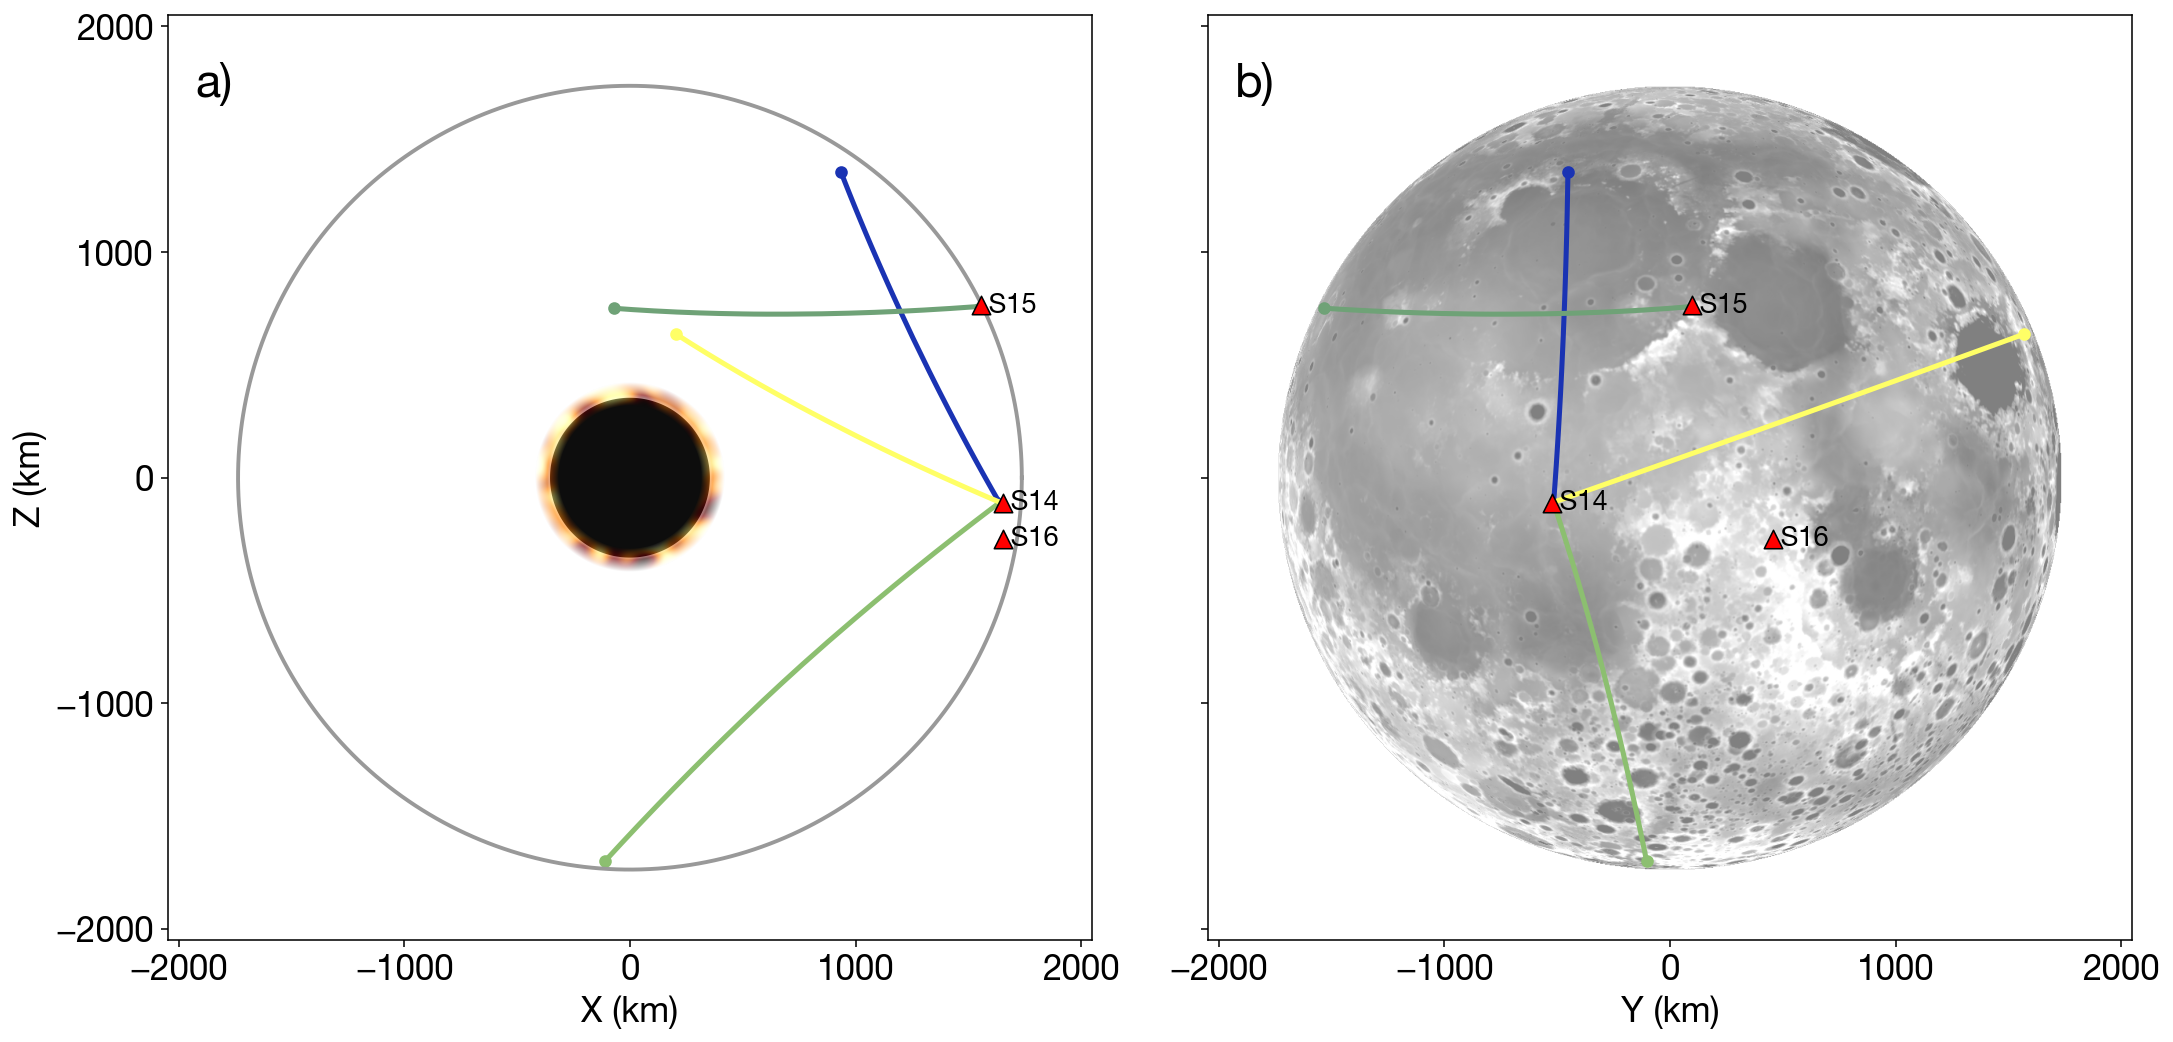

Final DataFrame used for plotting:
                                   event                         time_utc  \
0  1976-03-06 10:03:00.009000+00:00__S14 1976-03-06 10:15:48.794000+00:00   
1  1975-01-03 01:32:00.013000+00:00__S15 1975-01-03 01:47:03.344000+00:00   
2  1973-03-13 07:47:00.014000+00:00__S14 1973-03-13 08:01:35.960000+00:00   
3  1974-07-11 00:37:00.006000+00:00__S14 1974-07-11 00:52:15.850000+00:00   

  station     epi_deg   lat    Lon  
0     S14   56.580047  52.5  -25.8  
1     S15   83.980853  26.1  -92.7  
2     S14   88.890000 -84.9 -137.1  
3     S14  100.704577  21.9   82.6  

Perturbation results:
  station     epi_deg  src_lat  src_lon phase        T0_s      dT_s  \
0     S14   56.580047     52.5    -25.8     P  217.875729 -5.349025   
1     S15   83.980853     26.1    -92.7     P  300.843213 -4.714816   
2     S14   88.890000    -84.9   -137.1     P  313.807151 -5.225938   
3     S14  100.704577     21.9     82.6     P  342.414682 -7.283603   

      Tcorr_s  

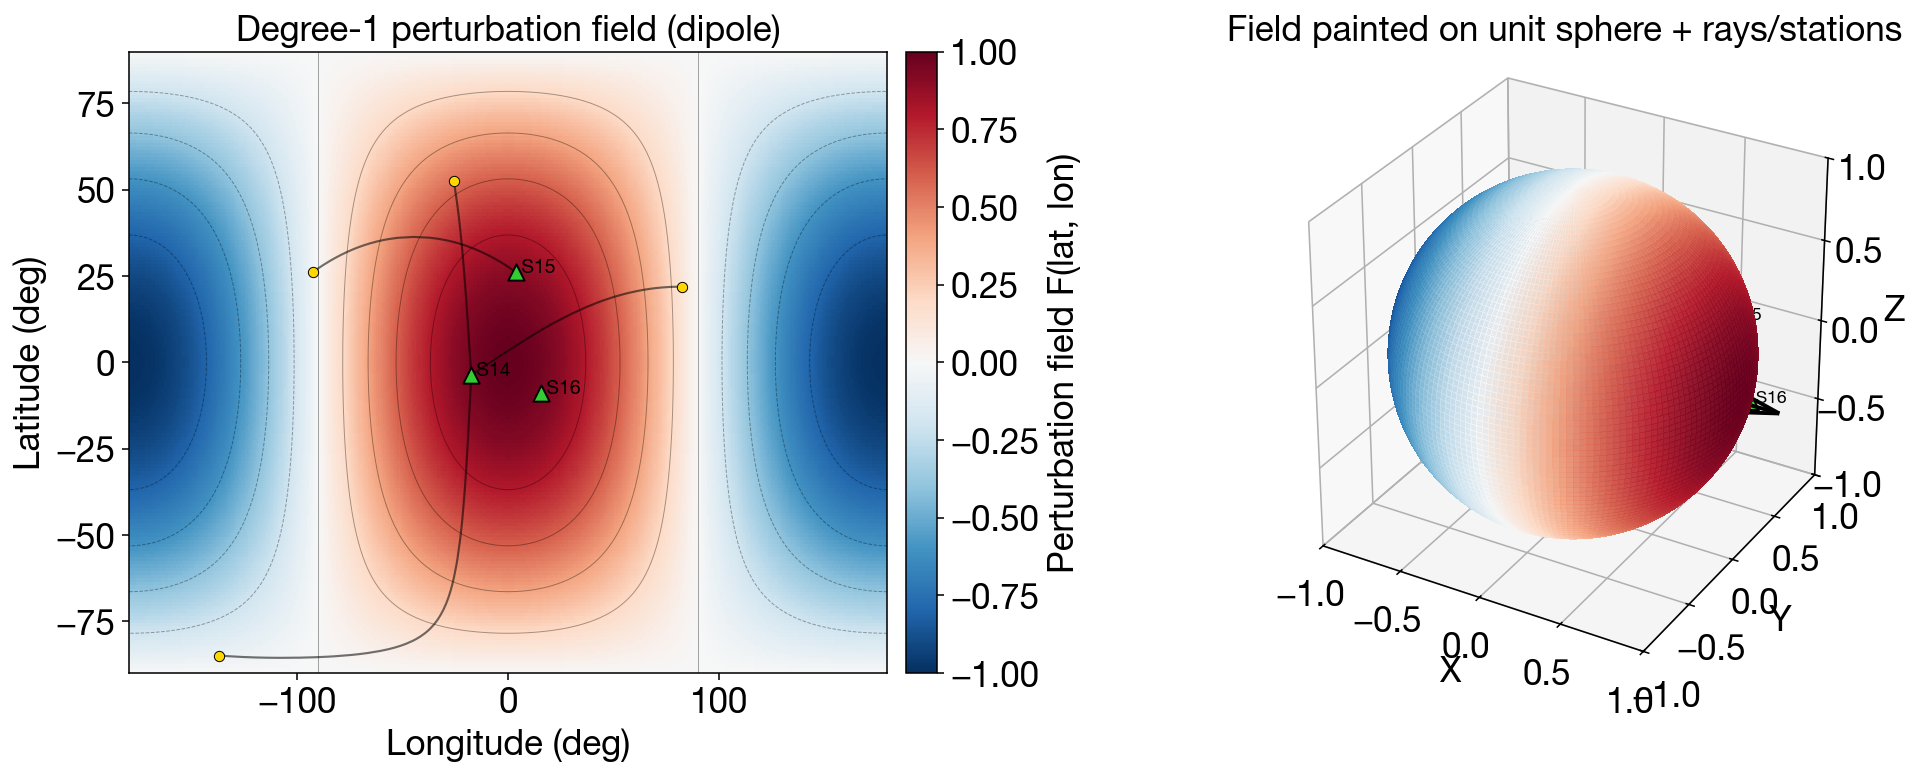

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel
import matplotlib as mpl
import matplotlib.colors as mcolors
import cmcrameri.cm as cmc
from matplotlib.patches import Wedge

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],

    "axes.titlesize": 18,     # subplot titles
    "axes.labelsize": 18,     # X/Y labels
    "xtick.labelsize": 18,    # x tick labels
    "ytick.labelsize": 18,    # y tick labels

    "axes.titleweight": "regular",
    "axes.labelweight": "regular",
})

# NEW
import pygmt
import xarray as xr

# -------------------- params --------------------
RMOON_KM     = 1737.1
SOURCE_DEPTH = 30
PHASE_LIST   = ["P"]
MODEL_NAME   = "vpremoon_mantle_closed"
PLOT_FIRST_ARRIVAL_ONLY = True
CORE_RADIUS_KM = 350.0

# NEW (topography controls)
TOPO_ALPHA = 0.5            # transparency of the topo texture
TOPO_RES_PIX = 1000           # texture resolution (pixels across the disk)
MOON_RELIEF_RES = "10m"      # pygmt moon relief resolution (e.g., "30m","10m","05m",...)
# -------------------- degree-1 perturbation controls --------------------
USE_DEG1_PERTURBATION = True
DEG1_EPS = 0.03
PRINT_PERTURBATION_SUMMARY = True


APOLLO_STATIONS = {
    "S16": {"lat": -8.9730, "lon": 15.5000},
    "S14": {"lat": -3.6440, "lon": -17.4775},
    "S15": {"lat": 26.1322, "lon": 3.6339},
}

# -------------------- helpers --------------------
def _xyz_from_latlon_depth(lat_rad, lon_rad, depth_km):
    r = RMOON_KM - depth_km
    clat = np.cos(lat_rad)
    x = r * clat * np.cos(lon_rad)
    y = r * clat * np.sin(lon_rad)
    z = r * np.sin(lat_rad)
    return x, y, z

def azimuth_deg(lat1_deg, lon1_deg, lat2_deg, lon2_deg):
    lat1 = np.deg2rad(lat1_deg); lon1 = np.deg2rad(lon1_deg)
    lat2 = np.deg2rad(lat2_deg); lon2 = np.deg2rad(lon2_deg)
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
    az = np.arctan2(x, y)
    return (np.rad2deg(az) + 360.0) % 360.0

def _ensure_radians(dist_array):
    d = np.asarray(dist_array, dtype=float)
    if np.nanmax(np.abs(d)) > (2*np.pi + 1e-6):
        return np.deg2rad(d)
    return d

def _forward_geodesic_sphere(lat1, lon1, az, sigma):
    sin_lat1 = np.sin(lat1); cos_lat1 = np.cos(lat1)
    sin_sigma = np.sin(sigma); cos_sigma = np.cos(sigma)
    lat2 = np.arcsin(sin_lat1*cos_sigma + cos_lat1*sin_sigma*np.cos(az))
    lon2 = lon1 + np.arctan2(np.sin(az)*sin_sigma*cos_lat1,
                             cos_sigma - sin_lat1*np.sin(lat2))
    lon2 = (lon2 + np.pi) % (2*np.pi) - np.pi
    return lat2, lon2

def _plot_masked_polyline_2d(ax, u, v, visible_mask, *, lw=1.6, color=None, zorder=5):
    u = np.asarray(u); v = np.asarray(v)
    m = np.asarray(visible_mask, dtype=bool)
    if u.size < 2 or m.sum() < 2:
        return
    idx = np.where(m)[0]
    splits = np.where(np.diff(idx) > 1)[0] + 1
    blocks = np.split(idx, splits)
    if color is None:
        color = ax._get_lines.get_next_color()
    for b in blocks:
        if b.size >= 2:
            ax.plot(u[b], v[b], lw=lw, color=color, zorder=zorder)

def _visible_mask_core_occlusion(x, y, z, view):
    """
    Orthographic views with a camera at +axis (or -axis) looking toward origin.
    Occlude by core disk: hide points inside the core disk that are behind the
    front hemisphere of the core, along the camera depth axis.
    """
    x = np.asarray(x); y = np.asarray(y); z = np.asarray(z)
    Rc = CORE_RADIUS_KM

    if view == "XZ":          # camera +Y, screen (x,z), depth=y
        u, v, d = x, z, y
    elif view == "XY":        # camera +Z, screen (x,y), depth=z
        u, v, d = x, y, z
    elif view == "XYm":       # camera -Z, screen (x,y), depth=-z
        u, v, d = x, y, -z
    elif view == "YZ":        # camera +X, screen (y,z), depth=x
        u, v, d = y, z, x
    elif view == "YZm":       # camera -X, screen (y,z), depth=-x
        u, v, d = y, z, -x
    else:
        raise ValueError("view_key must be 'XZ','XY','XYm','YZ','YZm'")

    r2 = u*u + v*v
    inside_disk = r2 < Rc*Rc
    front = np.sqrt(np.maximum(Rc*Rc - r2, 0.0))  # front hemisphere depth (>=0)
    visible = (~inside_disk) | (d >= front)
    return u, v, visible

def _latlon_from_xyz(x, y, z):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    z = np.asarray(z, float)
    r = np.sqrt(x*x + y*y + z*z)
    lat = np.arcsin(np.clip(z / r, -1.0, 1.0))
    lon = np.arctan2(y, x)
    return lat, lon

DEG1_KIND = "dipole"
DEG1_VECTOR = np.array([1.0, 0.0, 0.0])

def _deg1_field(lat, lon, kind="EW"):
    lat = np.asarray(lat, float)
    lon = np.asarray(lon, float)

    if kind == "NS":
        return np.sin(lat)

    if kind == "EW":
        return np.cos(lat) * np.cos(lon)

    if kind == "EW_sin":
        return np.cos(lat) * np.sin(lon)

    if kind == "dipole":
        a = np.asarray(DEG1_VECTOR, float)
        a = a / np.linalg.norm(a)
        ax, ay, az = a

        x = np.cos(lat) * np.cos(lon)
        y = np.cos(lat) * np.sin(lon)
        z = np.sin(lat)
        return ax * x + ay * y + az * z

    raise ValueError(f"Unknown DEG1 kind: {kind}")
def plot_degree1_field_on_sphere(
    kind=None,
    vector=None,
    nlat=181,
    nlon=361,
    out_df=None,
    plot_rays=True,
    plot_stations=True,
    first_arrival_only=True,
    source_depth_km=SOURCE_DEPTH,
    phase_list=PHASE_LIST,
    model_name=MODEL_NAME,
):
    """
    Plot the degree-1 perturbation field on the sphere, optionally overlaying
    sources, stations, and TauP raypaths.

    Parameters
    ----------
    kind : str
        One of "NS", "EW", "EW_sin", "dipole".
        If None, uses global DEG1_KIND.
    vector : array-like or None
        Dipole vector for kind="dipole". If None, uses global DEG1_VECTOR.
    nlat, nlon : int
        Grid resolution.
    out_df : pandas.DataFrame or None
        Event table containing at least: station, epi_deg, lat, Lon (or lon).
    plot_rays : bool
        If True, overlay ray paths.
    plot_stations : bool
        If True, overlay Apollo stations.
    first_arrival_only : bool
        If True, only plot the first arrival per source-station pair.
    """
    global DEG1_VECTOR

    if kind is None:
        kind = DEG1_KIND

    old_vec = DEG1_VECTOR.copy()
    if vector is not None:
        DEG1_VECTOR = np.asarray(vector, float)

    # ---------------- field grid ----------------
    lat_deg = np.linspace(-90, 90, nlat)
    lon_deg = np.linspace(-180, 180, nlon)
    Lon_deg, Lat_deg = np.meshgrid(lon_deg, lat_deg)

    lat = np.deg2rad(Lat_deg)
    lon = np.deg2rad(Lon_deg)

    F = _deg1_field(lat, lon, kind=kind)
    fmax = np.nanmax(np.abs(F))

    fig = plt.figure(figsize=(15, 6), dpi=140)

    # -------- map view --------
    ax1 = fig.add_subplot(1, 2, 1)
    im = ax1.pcolormesh(
        Lon_deg, Lat_deg, F,
        shading="auto",
        cmap="RdBu_r",
        vmin=-fmax,
        vmax= fmax,
    )
    cbar = plt.colorbar(im, ax=ax1, pad=0.02)
    cbar.set_label("Perturbation field F(lat, lon)")

    ax1.set_xlabel("Longitude (deg)")
    ax1.set_ylabel("Latitude (deg)")
    ax1.set_title(f"Degree-1 perturbation field ({kind})")
    ax1.set_xlim(-180, 180)
    ax1.set_ylim(-90, 90)

    ax1.contour(
        Lon_deg, Lat_deg, F,
        levels=9, colors="k", linewidths=0.5, alpha=0.35
    )

    # -------- 3D sphere view --------
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)

    norm = plt.Normalize(vmin=-fmax, vmax=fmax)
    facecolors = plt.cm.RdBu_r(norm(F))

    ax2.plot_surface(
        x, y, z,
        facecolors=facecolors,
        rstride=2, cstride=2,
        linewidth=0,
        antialiased=False,
        shade=False,
        alpha=0.92,
    )

    if kind == "dipole":
        a = np.asarray(DEG1_VECTOR, float)
        a = a / np.linalg.norm(a)
        ax2.quiver(
            0, 0, 0,
            a[0], a[1], a[2],
            length=1.25, linewidth=2, color="k"
        )

    # ---------------- overlay rays / stations ----------------
    if out_df is not None:
        df = out_df.copy()

        if "Lon" not in df.columns and "lon" in df.columns:
            df["Lon"] = df["lon"]

        df["station"] = df["station"].astype(str).str.strip()
        df["epi_deg"] = pd.to_numeric(df["epi_deg"], errors="coerce")
        df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
        df["Lon"] = pd.to_numeric(df["Lon"], errors="coerce")

        df = df[
            np.isfinite(df["epi_deg"]) &
            np.isfinite(df["lat"]) &
            np.isfinite(df["Lon"]) &
            df["station"].isin(APOLLO_STATIONS.keys())
        ].reset_index(drop=True)

        model = TauPyModel(model=model_name)

        ray_color = "k"
        ray_alpha_map = 0.55
        ray_alpha_3d = 0.45
        src_color = "gold"
        sta_color = "limegreen"

        # ---- stations ----
        if plot_stations:
            for sta, info in APOLLO_STATIONS.items():
                slat_deg = info["lat"]
                slon_deg = info["lon"]

                slat = np.deg2rad(slat_deg)
                slon = np.deg2rad(slon_deg)

                sx = np.cos(slat) * np.cos(slon)
                sy = np.cos(slat) * np.sin(slon)
                sz = np.sin(slat)

                # map
                ax1.scatter(
                    [slon_deg], [slat_deg],
                    marker="^", s=70,
                    color=sta_color, edgecolor="k", zorder=6
                )
                ax1.text(
                    slon_deg, slat_deg, f" {sta}",
                    fontsize=10, weight="bold", color="k", zorder=7
                )

                # sphere
                ax2.scatter(
                    [sx], [sy], [sz],
                    marker="^", s=60,
                    color=sta_color, edgecolor="k", depthshade=False
                )
                ax2.text(sx, sy, sz, f" {sta}", fontsize=9)

        # ---- sources + rays ----
        for _, row in df.iterrows():
            sta = row["station"]
            dist_deg = float(row["epi_deg"])
            src_lat_deg = float(row["lat"])
            src_lon_deg = float(row["Lon"])

            rec_lat_deg = float(APOLLO_STATIONS[sta]["lat"])
            rec_lon_deg = float(APOLLO_STATIONS[sta]["lon"])

            src_lat_rad = np.deg2rad(src_lat_deg)
            src_lon_rad = np.deg2rad(src_lon_deg)

            # source on unit sphere
            sx = np.cos(src_lat_rad) * np.cos(src_lon_rad)
            sy = np.cos(src_lat_rad) * np.sin(src_lon_rad)
            sz = np.sin(src_lat_rad)

            ax1.scatter(
                [src_lon_deg], [src_lat_deg],
                marker="o", s=28,
                color=src_color, edgecolor="k", linewidth=0.5, zorder=6
            )
            ax2.scatter(
                [sx], [sy], [sz],
                marker="o", s=24,
                color=src_color, edgecolor="k", linewidth=0.5, depthshade=False
            )

            if not plot_rays:
                continue

            arrivals = model.get_ray_paths(
                source_depth_in_km=source_depth_km,
                distance_in_degree=dist_deg,
                phase_list=phase_list
            )
            if not arrivals:
                continue

            if first_arrival_only:
                arrivals = [min(arrivals, key=lambda a: a.time)]

            az_rad = np.deg2rad(
                azimuth_deg(src_lat_deg, src_lon_deg, rec_lat_deg, rec_lon_deg)
            )

            for a in arrivals:
                dist_rad = _ensure_radians(a.path["dist"])
                depth_km = np.asarray(a.path["depth"], float)

                lat_i, lon_i = _forward_geodesic_sphere(
                    src_lat_rad, src_lon_rad, az_rad, dist_rad
                )

                # map track
                lon_i_deg = np.rad2deg(lon_i)
                lat_i_deg = np.rad2deg(lat_i)

                # break at wraparound to avoid long line across map
                jumps = np.abs(np.diff(lon_i_deg)) > 180
                if np.any(jumps):
                    split_idx = np.where(jumps)[0] + 1
                    lon_blocks = np.split(lon_i_deg, split_idx)
                    lat_blocks = np.split(lat_i_deg, split_idx)
                    for xb, yb in zip(lon_blocks, lat_blocks):
                        if len(xb) >= 2:
                            ax1.plot(
                                xb, yb,
                                color=ray_color, lw=1.1,
                                alpha=ray_alpha_map, zorder=5
                            )
                else:
                    ax1.plot(
                        lon_i_deg, lat_i_deg,
                        color=ray_color, lw=1.1,
                        alpha=ray_alpha_map, zorder=5
                    )

                # 3D ray path
                r_i = RMOON_KM - depth_km
                r_unit = r_i / RMOON_KM

                clat = np.cos(lat_i)
                x_i = r_unit * clat * np.cos(lon_i)
                y_i = r_unit * clat * np.sin(lon_i)
                z_i = r_unit * np.sin(lat_i)

                ax2.plot(
                    x_i, y_i, z_i,
                    color=ray_color, lw=1.1, alpha=ray_alpha_3d
                )

    # cosmetics
    ax2.set_title("Field painted on unit sphere + rays/stations")
    ax2.set_box_aspect([1, 1, 1])
    ax2.set_xlim([-1, 1])
    ax2.set_ylim([-1, 1])
    ax2.set_zlim([-1, 1])
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")

    plt.tight_layout()
    plt.show()

    DEG1_VECTOR = old_vec
def _compute_degree1_dt_from_ray(x, y, z, time_s, eps, kind="EW"):
    """
    First-order travel-time correction along a fixed TauP ray:
        deltaT ≈ -eps ∫ F(lat, lon) dt

    Uses midpoint rule on the sampled TauP path.

    Parameters
    ----------
    x, y, z : arrays
        Cartesian coordinates of the TauP ray samples.
    time_s : array
        Cumulative travel time samples along the ray.
    eps : float
        Perturbation amplitude.
    kind : str
        Degree-1 perturbation type.

    Returns
    -------
    deltaT : float
        First-order travel-time perturbation in seconds.
    field_mid : ndarray
        Midpoint field values used in the integral.
    dt_seg : ndarray
        Time increments for each path segment.
    """
    time_s = np.asarray(time_s, float)
    order = np.argsort(time_s)

    x = np.asarray(x, float)[order]
    y = np.asarray(y, float)[order]
    z = np.asarray(z, float)[order]
    time_s = time_s[order]

    if time_s.size < 2:
        return 0.0, np.array([], float), np.array([], float)

    lat, lon = _latlon_from_xyz(x, y, z)
    field = _deg1_field(lat, lon, kind=kind)

    dt_seg = np.diff(time_s)
    field_mid = 0.5 * (field[:-1] + field[1:])

    deltaT = -eps * np.sum(field_mid * dt_seg)
    return float(deltaT), field_mid, dt_seg
# -------------------- NEW: DEM loading + fast bilinear sampling --------------------
def _infer_lon_mode_from_grid(grid: xr.DataArray):
    lon_coord = None
    for name in ("lon", "longitude", "x"):
        if name in grid.coords:
            lon_coord = name
            break
    if lon_coord is None:
        return "360", "lon", "lat"
    vals = grid[lon_coord].values
    vmin, vmax = np.nanmin(vals), np.nanmax(vals)
    if vmin >= 0 and vmax <= 360:
        return "360", lon_coord, "lat" if "lat" in grid.coords else "y"
    if vmin >= -180 and vmax <= 180:
        return "180", lon_coord, "lat" if "lat" in grid.coords else "y"
    return "360", lon_coord, "lat" if "lat" in grid.coords else "y"

def _wrap_lon(lon_deg, mode):
    if mode == "360":
        return lon_deg % 360.0
    # (-180, 180]
    x = (lon_deg + 180.0) % 360.0 - 180.0
    return np.where(np.isclose(x, -180.0), 180.0, x)

def _prep_dem(dem_grid_path=None, resolution="10m"):
    if dem_grid_path is None:
        grid = pygmt.datasets.load_moon_relief(resolution=resolution)
    elif isinstance(dem_grid_path, str) and dem_grid_path.lower() in {
        "01d","30m","20m","15m","10m","06m","05m","04m","03m","02m","01m"
    }:
        grid = pygmt.datasets.load_moon_relief(resolution=dem_grid_path.lower())
    else:
        grid = pygmt.load_dataarray(dem_grid_path)

    mode, lon_name, lat_name = _infer_lon_mode_from_grid(grid)
    lon = np.asarray(grid[lon_name].values, float)
    lat = np.asarray(grid[lat_name].values, float)
    data = np.asarray(grid.values, float)

    # enforce increasing coords (common DEMs already are, but keep it robust)
    if lon[0] > lon[-1]:
        lon = lon[::-1]
        data = data[:, ::-1]
    if lat[0] > lat[-1]:
        lat = lat[::-1]
        data = data[::-1, :]

    return {"mode": mode, "lon": lon, "lat": lat, "z": data}

def _bilinear_sample_dem(dem, lat_deg, lon_deg):
    """
    Vectorized bilinear sampling on a regular lat/lon grid.
    lat_deg, lon_deg arrays same shape; returns sampled z with NaNs preserved.
    """
    latq = np.asarray(lat_deg, float)
    lonq = _wrap_lon(np.asarray(lon_deg, float), dem["mode"])

    z = dem["z"]
    lon = dem["lon"]
    lat = dem["lat"]

    out = np.full(latq.shape, np.nan, float)

    good = np.isfinite(latq) & np.isfinite(lonq)
    if not np.any(good):
        return out

    latv = latq[good]
    lonv = lonq[good]

    # indices
    i = np.searchsorted(lat, latv) - 1
    j = np.searchsorted(lon, lonv) - 1
    i = np.clip(i, 0, len(lat) - 2)
    j = np.clip(j, 0, len(lon) - 2)

    lat0 = lat[i]; lat1 = lat[i + 1]
    lon0 = lon[j]; lon1 = lon[j + 1]

    # weights (avoid div0)
    wy = np.where(lat1 != lat0, (latv - lat0) / (lat1 - lat0), 0.0)
    wx = np.where(lon1 != lon0, (lonv - lon0) / (lon1 - lon0), 0.0)

    z00 = z[i, j]
    z01 = z[i, j + 1]
    z10 = z[i + 1, j]
    z11 = z[i + 1, j + 1]

    zv = (1 - wy) * ((1 - wx) * z00 + wx * z01) + wy * ((1 - wx) * z10 + wx * z11)
    out[good] = zv
    return out

def _make_topo_texture_for_view(dem, view_key, npix=700, r_km=RMOON_KM):
    """
    Build an orthographic texture of Moon relief for one of: XZ (cam +Y), YZ (cam +X), XY (cam +Z).
    Returns (img, extent) suitable for imshow.
    """
    u = np.linspace(-r_km, r_km, npix)
    v = np.linspace(-r_km, r_km, npix)
    U, V = np.meshgrid(u, v)  # U horizontal, V vertical

    r2 = U*U + V*V
    inside = r2 <= r_km*r_km

    img = np.full((npix, npix), np.nan, float)
    front = np.sqrt(np.maximum(r_km*r_km - r2, 0.0))

    if view_key == "XZ":
        # u=x, v=z, camera depth is +y
        X = U
        Z = V
        Y = front
        lat = np.rad2deg(np.arcsin(np.clip(Z / r_km, -1, 1)))
        lon = np.rad2deg(np.arctan2(Y, X))
    elif view_key == "YZ":
        Y = U; Z = V; X = front       # camera +X
        lat = np.rad2deg(np.arcsin(np.clip(Z / r_km, -1, 1)))
        lon = np.rad2deg(np.arctan2(Y, X))

    elif view_key == "YZm":
        Y = -U
        Z = V
        X = -front
        lat = np.rad2deg(np.arcsin(np.clip(Z / r_km, -1, 1)))
        lon = np.rad2deg(np.arctan2(Y, X))

    elif view_key == "XY":
        # u=x, v=y, camera depth is +z  (near side)
        X = U
        Y = V
        Z = front
        lat = np.rad2deg(np.arcsin(np.clip(Z / r_km, -1, 1)))
        lon = np.rad2deg(np.arctan2(Y, X))

    elif view_key == "XYm":
        # u=x, v=y, camera depth is -z  (far side)
        X = U
        Y = V
        Z = -front
        lat = np.rad2deg(np.arcsin(np.clip(Z / r_km, -1, 1)))
        lon = np.rad2deg(np.arctan2(Y, X))
    else:
        raise ValueError("view_key must be 'XZ', 'XY', or 'XYm'")


    lat = np.where(inside, lat, np.nan)
    lon = np.where(inside, lon, np.nan)

    relief = _bilinear_sample_dem(dem, lat, lon)
    img[:] = relief

    # extent in km for imshow
    extent = [-r_km, r_km, -r_km, r_km]
    return img, extent

# -------------------- main --------------------
def plot_rays_3views_with_core_occlusion(out_df, dem_grid_path=None):
    df = out_df.copy()
    n0 = len(df)

    # after numeric coercions but before filtering
    bad_epi = df["epi_deg"].isna().sum()
    bad_lat = df["lat"].isna().sum()
    bad_lon = df["Lon"].isna().sum() if "Lon" in df.columns else None

    # after filtering (your existing df = df[ ... ])
    n1 = len(df)

    print(f"Start rows: {n0}")
    print(f"NaN after coercion -> epi:{bad_epi}, lat:{bad_lat}, lon:{bad_lon}")
    print(f"After finite+station filter: {n1}")
    print("Station counts after filter:\n", df["station"].value_counts(dropna=False))
    df["station"] = df["station"].astype(str).str.strip()

    if "Lon" not in df.columns and "lon" in df.columns:
        df["Lon"] = df["lon"]

    df["epi_deg"] = pd.to_numeric(df["epi_deg"], errors="coerce")
    df["lat"]     = pd.to_numeric(df["lat"], errors="coerce")
    df["Lon"]     = pd.to_numeric(df["Lon"], errors="coerce")

    df = df[
        np.isfinite(df["epi_deg"]) &
        np.isfinite(df["lat"]) &
        np.isfinite(df["Lon"]) &
        df["station"].isin(APOLLO_STATIONS.keys())
    ].reset_index(drop=True)
    df_final = df.copy()  # keep a copy of the final filtered df for plotting
    if df.empty:
        raise ValueError("No valid rows to plot after filtering.")

    # NEW: load DEM once and pre-build textures for each view
    dem = _prep_dem(dem_grid_path=dem_grid_path, resolution=MOON_RELIEF_RES)
    topo_textures = {}
    for view_key in ("XZ", "YZ", "YZm"):
        topo_textures[view_key] = _make_topo_texture_for_view(dem, view_key, npix=TOPO_RES_PIX)

    model = TauPyModel(model=MODEL_NAME)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(16, 9),
        dpi=140,
        sharey=True
    )

    views = [
        ("Earth to the east", "XZ", "X (km)", "Z (km)"),
        ("Near side",         "YZ", "Y (km)", "Z (km)"),
    ]
    out_CORE_RADIUS_KMinner = CORE_RADIUS_KM * 0.98
    out_CORE_RADIUS_KMouter = CORE_RADIUS_KM * 1.2
    theta = np.linspace(0, 2*np.pi, 600)    
    moon_u = RMOON_KM * np.cos(theta)
    moon_v = RMOON_KM * np.sin(theta)
    core_u = CORE_RADIUS_KM * np.cos(theta)
    core_v = CORE_RADIUS_KM * np.sin(theta)
    core_inner = CORE_RADIUS_KM
    core_outer = CORE_RADIUS_KM * 1.20   # ring outer radius

    



    for i, (ax, (title, view_key, xlab, ylab)) in enumerate(zip(axes, views)):

        # ---------------- Panel-specific simplifications ----------------
        draw_topo = (i != 0)   # left plot (i==0): NO lunar topography
        draw_core = (i != 1)   # right plot (i==1): NO core disk ("there")
        draw_ring = (i != 1)   # right plot (i==1): NO outer ring
        # ----------------------------------------------------------------

        # ---- optional topo background ----
        if draw_topo:
            if dem is None:
                dem = _prep_dem(dem_grid_path=dem_grid_path, resolution=MOON_RELIEF_RES)
            if view_key not in topo_textures:
                topo_textures[view_key] = _make_topo_texture_for_view(
                    dem, view_key, npix=TOPO_RES_PIX
                )
            img, extent = topo_textures[view_key]
            vmin, vmax = np.nanpercentile(img, [2, 98])
            ax.imshow(
                img, extent=extent, origin="lower",
                alpha=TOPO_ALPHA, cmap="gray", vmin=vmin, vmax=vmax, zorder=0
            )
        if i == 0:
            ax.plot(moon_u, moon_v, color="0.6", lw=2.0, zorder=6)

        # ---- optional core disk ----
        if draw_core:
            ax.fill(core_u, core_v, color="0.05", alpha=1.0, zorder=2)

        # ---- optional blob ring annulus ----
        if draw_ring:
            core_inner = CORE_RADIUS_KM * 0.90
            core_outer = CORE_RADIUS_KM * 1.20

            npix = 500
            x = np.linspace(-core_outer, core_outer, npix)
            y = np.linspace(-core_outer, core_outer, npix)
            X, Y = np.meshgrid(x, y)
            R = np.sqrt(X**2 + Y**2)

            noise = np.random.rand(npix, npix)
            from scipy.ndimage import gaussian_filter
            noise = gaussian_filter(noise, sigma=20)

            mask = (R >= core_inner) & (R <= core_outer)
            blob_field = np.where(mask, noise, np.nan)

            fade_km = 80.0
            d_to_inner = R - core_inner
            d_to_outer = core_outer - R
            d = np.minimum(d_to_inner, d_to_outer)

            alpha_ring = np.clip(d / fade_km, 0.0, 1.0)
            alpha_ring[~mask] = 0.0

            ax.imshow(
                blob_field,
                extent=[-core_outer, core_outer, -core_outer, core_outer],
                origin="lower",
                cmap="afmhot",
                alpha=alpha_ring,
                zorder=3
            )

        # ---- rest of your formatting as-is ----
        ax.set_aspect("equal")
        ax.set_xlabel(xlab)
        ax.set_ylabel(ylab)
        lim = RMOON_KM * 1.18
        base_ticks = np.arange(-2000, 2001, 1000)
        ax.set_xticks(base_ticks)
        ax.set_yticks(base_ticks)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        axes[0].set_ylabel("Z (km)")
        for ax2 in axes[1:]:
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)

    for sta, info in APOLLO_STATIONS.items():
        rlat = np.deg2rad(info["lat"])
        rlon = np.deg2rad(info["lon"])
        xs, ys, zs = _xyz_from_latlon_depth(rlat, rlon, 0.0)

        for ax, (_, view_key, _, _) in zip(axes, views):
            if view_key == "XZ":
                u, v = xs, zs
            elif view_key in ("YZ", "YZm"):
                u, v = ys, zs
            else:
                raise ValueError(view_key)
            STATION_TRI_COLOR = "red"
            STATION_TRI_SIZE  = 90      # triangle size
            STATION_LABEL_FS  = 14      # label fontsize

            ax.scatter([u], [v],
                    marker="^",
                    s=STATION_TRI_SIZE,
                    facecolor=STATION_TRI_COLOR,
                    edgecolor="black",   # optional but helps visibility
                    linewidth=0.8,
                    zorder=6)

            ax.text(u, v, f" {sta}",
                    fontsize=STATION_LABEL_FS,
                    fontweight="bold",      # optional
                    va="center",
                    color="black",          # keep readable; change if you want
                    zorder=7)

    panel_labels = ["a)", "b)"]

    for i, (ax, (title, view_key, xlab, ylab)) in enumerate(zip(axes, views)):
        ax.set_xlabel(xlab)
        ax.text(0.03, 0.95, panel_labels[i],
                transform=ax.transAxes, fontsize=24, fontweight="bold",
                va="top", ha="left")

    cmap = cmc.imola
    norm = mcolors.Normalize(vmin=df["epi_deg"].min(), vmax=df["epi_deg"].max())

    # >>> NEW: counters
    n_rows_considered = 0
    n_rows_with_arrivals = 0
    n_rays_plotted = 0  # counts actual raypaths drawn (after first-arrival selection)
    # <<<
    no_arrivals = []
    perturbation_rows = []

    for _, row in df.iterrows():
        n_rows_considered += 1

        sta = row["station"]
        dist_deg = float(row["epi_deg"])
        src_lat_deg = float(row["lat"])
        src_lon_deg = float(row["Lon"])

        rec_lat_deg = float(APOLLO_STATIONS[sta]["lat"])
        rec_lon_deg = float(APOLLO_STATIONS[sta]["lon"])

        arrivals = model.get_ray_paths(
            source_depth_in_km=SOURCE_DEPTH,
            distance_in_degree=dist_deg,
            phase_list=PHASE_LIST
        )
        if not arrivals:
            no_arrivals.append((row["station"], float(row["epi_deg"])))
            continue


        n_rows_with_arrivals += 1

        if PLOT_FIRST_ARRIVAL_ONLY:
            arrivals = [min(arrivals, key=lambda a: a.time)]

        az_rad = np.deg2rad(azimuth_deg(src_lat_deg, src_lon_deg, rec_lat_deg, rec_lon_deg))
        src_lat_rad = np.deg2rad(src_lat_deg)
        src_lon_rad = np.deg2rad(src_lon_deg)

        for a in arrivals:
            n_rays_plotted += 1  # <<< NEW: counts each drawn raypath

            dist_rad = _ensure_radians(a.path["dist"])
            depth_km = np.asarray(a.path["depth"], float)
            time_s   = np.asarray(a.path["time"], float)

            lat_i, lon_i = _forward_geodesic_sphere(src_lat_rad, src_lon_rad, az_rad, dist_rad)

            r_i  = RMOON_KM - depth_km
            clat = np.cos(lat_i)
            x = r_i * clat * np.cos(lon_i)
            y = r_i * clat * np.sin(lon_i)
            z = r_i * np.sin(lat_i)

            if USE_DEG1_PERTURBATION:
                dT, field_mid, dt_seg = _compute_degree1_dt_from_ray(
                    x, y, z, time_s, eps=DEG1_EPS, kind=DEG1_KIND
                )
            else:
                dT = 0.0
                field_mid = np.array([], float)
                dt_seg = np.array([], float)

            T0 = float(a.time)
            Tcorr = T0 + dT
            color = cmap(norm(dist_deg))
            for ax, (_, view_key, _, _) in zip(axes, views):
                u, v, vis = _visible_mask_core_occlusion(x, y, z, view_key)
                _plot_masked_polyline_2d(ax, u, v, vis, lw=2.6, zorder=4, color=color)
                u0 = u[0]
                v0 = v[0]

                # only draw if visible in that view
                if vis[0]:
                    ax.scatter(u0, v0,
                            s=30,          # marker size
                            color=color,
                            zorder=5)
                    
            perturbation_rows.append({
                "station": sta,
                "epi_deg": dist_deg,
                "src_lat": src_lat_deg,
                "src_lon": src_lon_deg,
                "phase": a.name,
                "T0_s": T0,
                "dT_s": dT,
                "Tcorr_s": Tcorr,
            })

    # >>> NEW: print summary
    perturbation_df = pd.DataFrame(perturbation_rows)

    print(
        f"Rows considered: {n_rows_considered} | "
        f"rows with arrivals: {n_rows_with_arrivals} | "
        f"raypaths plotted: {n_rays_plotted}"
    )

    if USE_DEG1_PERTURBATION and not perturbation_df.empty:
        print("\nTravel-time correction summary (s):")
        print(perturbation_df[["T0_s", "dT_s", "Tcorr_s"]].describe().round(3))

    plt.tight_layout()
    plt.show()
    return df_final, perturbation_df
# ---- run ----

df_final, perturbation_df = plot_rays_3views_with_core_occlusion(out_df, dem_grid_path=None)

print("Final DataFrame used for plotting:")
print(df_final)

print("\nPerturbation results:")
print(perturbation_df)
plot_degree1_field_on_sphere(
    kind=DEG1_KIND,
    vector=DEG1_VECTOR,
    out_df=df_final,   # or out_df if you want the raw table
    plot_rays=True,
    plot_stations=True,
    first_arrival_only=True,
)

Allowed events from df_final: 4
                                   event                         time_utc
0  1976-03-06 10:03:00.009000+00:00__S14 1976-03-06 10:15:48.794000+00:00
1  1975-01-03 01:32:00.013000+00:00__S15 1975-01-03 01:47:03.344000+00:00
2  1973-03-13 07:47:00.014000+00:00__S14 1973-03-13 08:01:35.960000+00:00
3  1974-07-11 00:37:00.006000+00:00__S14 1974-07-11 00:52:15.850000+00:00
Filtered df_long by df_final events: 4/43 remain
Matched 4 Excel events to MiniSEED traces (tol=2.0s).
Kept by dt_rel criteria: 4/4
 Kept with MiniSEED match: 4/4
LOWER_TOL=0.75_MIN_POST=4_K_NEG=0_K_PRE_POS=0


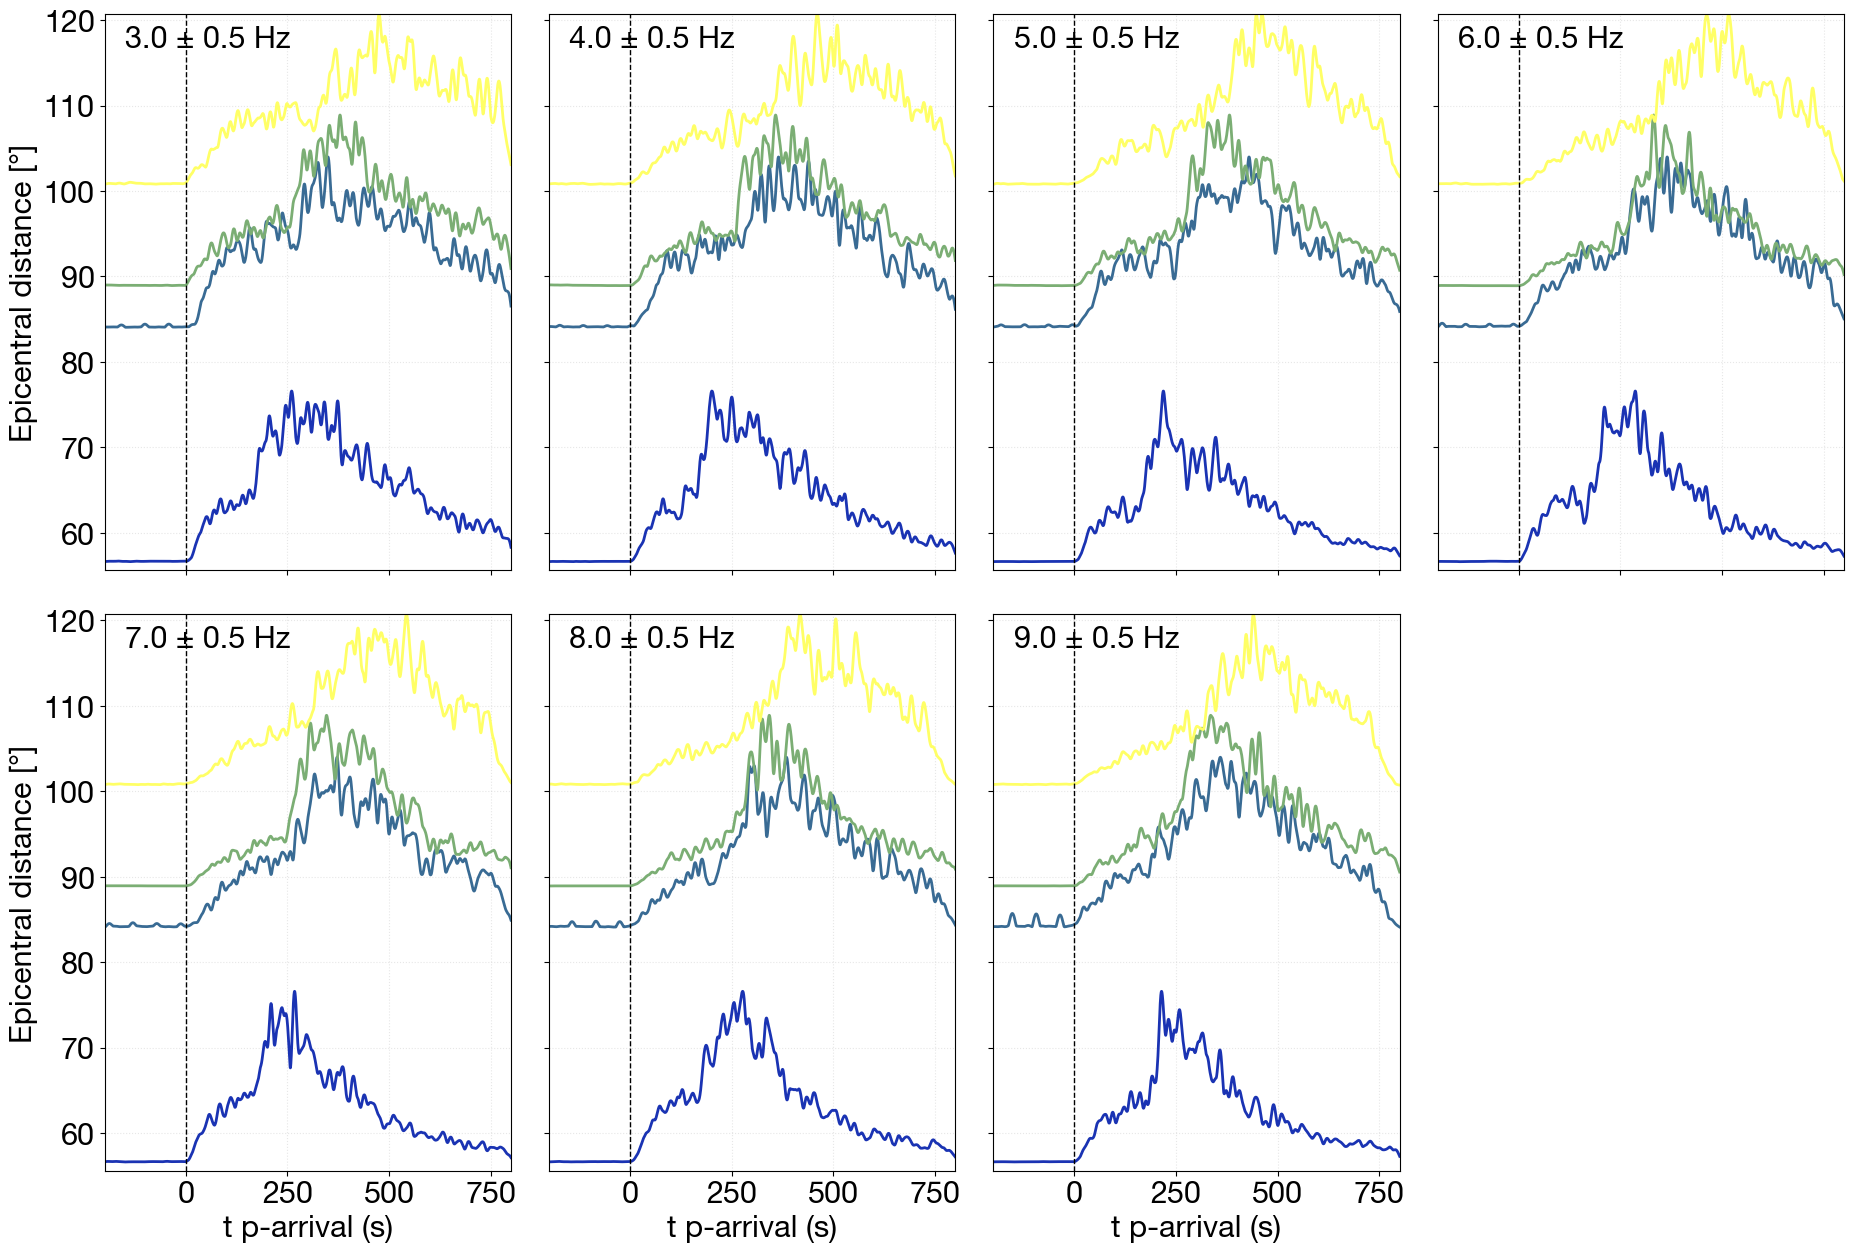

 Saved: /Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/results/LSQ_Fitting/Single_Plots/Envelope_distance_win20_LOWER_TOL=0.75_MIN_POST=4_K_NEG=0_K_PRE_POS=0.pdf


In [23]:
# ============================================================
# Plot distance-gather RMS(envelope) aligned on band t0_dt_mean
# Match events by: (station, MiniSEED trace starttime) <-> Excel starttime
# Only win_s = 20 seconds
# Color: Batlow, low->high epicentral distance (per band)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import read, UTCDateTime
from scipy.signal import butter, sosfiltfilt, hilbert, get_window
from cmcrameri import cm as cmc
# If df_final is already in memory, skip this.
# df_final = pd.read_parquet("df_final.parquet")
# df_final = pd.read_csv("df_final.csv")

df_final = df_final.copy()
df_final["event"] = df_final["event"].astype(str).str.strip()
allowed_events = set(df_final["event"].unique())

print(f"Allowed events from df_final: {len(allowed_events)}")
print(df_final[["event", "time_utc"]].head())


# -------------------------
# CONFIG
# -------------------------
xlsx  = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
sheet = "best_7_bands_fixed_hold0"

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"

# Band setup
FC      = 5.0
BANDS   = np.array([3., 4., 5., 6., 7., 8., 9.])
CENTERS = BANDS.copy()
HALF_BW = 0.5
BP_ORDER = 4

# RMS envelope smoothing window (ONLY this)
WIN_S = 20

# Time window around band t0 (seconds)
T_BEFORE = 200
T_AFTER  = 800

# Matching tolerance between MiniSEED trace starttime and Excel starttime (seconds)
STARTTIME_TOL_S = 2.0

# Output
SAVE_DIR = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/results/LSQ_Fitting/Single_Plots/"
os.makedirs(SAVE_DIR, exist_ok=True)

# # Selection scenarios (your logic)
# SCENARIOS = [
#     dict(name="tol0.75_post2_kneg1_prepos1", LOWER_TOL=0.75, MIN_POST=0, K_NEG=5, K_PRE_POS=2),
# ]

# Plot aesthetics
plt.rcParams.update({
    "font.family": "Helvetica Neue",
    "font.size": 22,
    "axes.labelsize": 22,
    "axes.titlesize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
})


# -------------------------
# SIGNAL HELPERS
# -------------------------
def band_edges(fc, half_bw, fs):
    fl = max(fc - half_bw, 0.001)
    fu = min(fc + half_bw, 0.99 * fs / 2)
    return fl, fu

def env_and_rms(x, fs, fl, fu, win_s, order):
    sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
    bp  = sosfiltfilt(sos, x)
    env = np.abs(hilbert(bp))

    N = int(round(win_s * fs)) | 1  # odd length
    w = get_window("hann", N)
    w = w / w.sum()

    rms = np.sqrt(np.convolve(env**2, w, mode="same"))
    return env, rms


# -------------------------
# EXCEL LOADING / NORMALIZATION
# -------------------------
def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(f"Missing columns in sheet '{sheet}': {missing}\nAvailable: {list(d.columns)}")

    # Parse types
    d["station"] = d["station"].astype(str)
    d["fc_hz"] = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)

    # starttime: accept strings, datetimes, etc.
    d["starttime_dt"] = pd.to_datetime(d["starttime"], errors="coerce", utc=True)

    # t0_dt_mean must be absolute datetime
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    # distance handling
    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    # keep only relevant bands
    d = d[d["fc_hz"].isin(BANDS)].copy()

    # event key based on Excel notion of event (station + starttime)
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    # compute dt_rel relative to FC per event
    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    # drop rows missing dt_rel or key timing fields
    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    dt_mat = (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )
    return dt_mat


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands  = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False); continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False); continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False); continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


# -------------------------
# MATCH MSEED EVENTS TO EXCEL EVENTS
# -------------------------
def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")

        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]

            if ev in event_to_trace:
                prev_tr, prev_diff = event_to_trace[ev]
                if dt.loc[j] < prev_diff:
                    event_to_trace[ev] = (tr, float(dt.loc[j]))
            else:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


# -------------------------
# MAIN
# -------------------------
# -------------------------
# MAIN
# -------------------------
df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)

# >>> filter HERE (df_long exists now)
before = df_long["event"].nunique()
df_long = df_long[df_long["event"].isin(allowed_events)].copy()
after = df_long["event"].nunique()
print(f"Filtered df_long by df_final events: {after}/{before} remain")
# <<<

dt_mat  = build_event_band_matrix(df_long, BANDS=BANDS)

t0_lookup = (
    df_long[["event", "band", "t0_dt_mean_dt"]]
    .drop_duplicates(subset=["event", "band"])
    .set_index(["event", "band"])["t0_dt_mean_dt"]
)

dist_map = (
    df_long[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

# df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)
# dt_mat  = build_event_band_matrix(df_long, BANDS=BANDS)

# t0_lookup = (
#     df_long[["event", "band", "t0_dt_mean_dt"]]
#     .drop_duplicates(subset=["event", "band"])
#     .set_index(["event", "band"])["t0_dt_mean_dt"]
# )

# dist_map = (
#     df_long[["event", "distance_deg"]]
#     .drop_duplicates(subset=["event"])
#     .set_index("event")["distance_deg"]
#     .to_dict()
# )

# st = read(MSEED_PATH)
# event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
# print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

for cfg in SCENARIOS:
    # name      = cfg["name"]
    LOWER_TOL = float(cfg["LOWER_TOL"])
    MIN_POST  = int(cfg["MIN_POST"])
    K_NEG     = int(cfg["K_NEG"])
    K_PRE_POS = int(cfg["K_PRE_POS"])

    keep_mask = select_events(
        dt_mat=dt_mat, FC=FC, BANDS=BANDS,
        MIN_POST=MIN_POST, K_NEG=K_NEG, K_PRE_POS=K_PRE_POS,
        LOWER_TOL=LOWER_TOL
    )

    kept_events = keep_mask.index[keep_mask].tolist()
    n_kept, n_tot = int(keep_mask.sum()), int(len(keep_mask))
    print(f"Kept by dt_rel criteria: {n_kept}/{n_tot}")

    kept_events = [ev for ev in kept_events if ev in event_to_trace]
    print(f" Kept with MiniSEED match: {len(kept_events)}/{n_kept}")
    if not kept_events:
        print(f" No events to plot after MiniSEED matching.")
        continue
    print(f"LOWER_TOL={LOWER_TOL}_MIN_POST={MIN_POST}_K_NEG={K_NEG}_K_PRE_POS={K_PRE_POS}")

    # Build (event, distance) list and sort by distance
    ev_dist = [(ev, float(dist_map.get(ev, np.nan))) for ev in kept_events]
    ev_dist = [(ev, d) for ev, d in ev_dist if np.isfinite(d)]
    ev_dist.sort(key=lambda x: x[1])

    if not ev_dist:
        print(f" No finite distances among kept events.")
        continue

    dist_min = ev_dist[0][1]
    dist_max = ev_dist[-1][1]

    # ------------------------------------------------------------
    # Assign Batlow colors by distance rank (low->high)
    # (No Normalize, no colormap scaling inside plotting)
    # ------------------------------------------------------------
    nE = len(ev_dist)
    if nE == 1:
        frac = np.array([0.5])
    else:
        frac = np.linspace(0.0, 1.0, nE)

    # event -> rgba
    event_color = {ev: cmc.imola(f) for (ev, _), f in zip(ev_dist, frac)}

    # Plot
    AMP_SCALE_DEG = 20  # scale of wiggle in degrees

    fig, axes = plt.subplots(2, 4, figsize=(19, 13), sharex="all", sharey="row")
    axes = axes.flatten()

    for i, fc in enumerate(CENTERS):
        ax = axes[i]

        n_have_t0 = n_plotted = 0

        for ev, dist in ev_dist:
            key = (ev, float(fc))
            if key not in t0_lookup.index:
                continue

            t0_dt = t0_lookup.loc[key]
            if pd.isna(t0_dt):
                continue
            n_have_t0 += 1

            tr = event_to_trace[ev]

            # window around band t0
            t0 = UTCDateTime(pd.Timestamp(t0_dt).to_pydatetime())
            t1, t2 = t0 - T_BEFORE, t0 + T_AFTER

            trc = tr.copy()
            try:
                trc.trim(t1, t2, pad=True, fill_value=0.0)
            except Exception:
                continue

            fs = float(trc.stats.sampling_rate)
            u  = trc.data.astype(float)
            if u.size < 10:
                continue

            t_rel = np.arange(len(u)) / fs - T_BEFORE

            fl, fu = band_edges(fc, HALF_BW, fs)
            _, rms = env_and_rms(u, fs, fl, fu, WIN_S, BP_ORDER)

            max_rms = np.nanmax(rms)
            if not np.isfinite(max_rms) or max_rms <= 0:
                continue

            rms_norm = rms / max_rms
            y = dist + AMP_SCALE_DEG * rms_norm

            ax.plot(
                t_rel, y,
                lw=2,
                color=event_color[ev],
                alpha=1,
            )
            n_plotted += 1

        ax.text(0.05, 0.98, f"{fc:.1f} ± {HALF_BW} Hz",
                ha="left", va="top", transform=ax.transAxes)
        ax.grid(True, ls=":", alpha=0.3)
        ax.axvline(0, color="k", ls="--", lw=1.0)
        ax.set_xlim(-T_BEFORE, T_AFTER)
        ax.set_ylim(dist_min - 1.0, dist_max + 20)

        if i % 4 == 0:
            ax.set_ylabel("Epicentral distance [°]")
        if i >= 4:
            ax.set_xlabel("t p-arrival (s)")

    if len(CENTERS) < 8:
        axes[-1].axis("off")

    # fig.suptitle(
    #     f"{name} | {len(ev_dist)}/{n_tot} events (after match) | win={WIN_S}s | aligned on t0_dt_mean(band)",
    #     y=0.98
    # )
    fig.tight_layout()

    out = os.path.join(SAVE_DIR, f"Envelope_distance_win{WIN_S:02d}_LOWER_TOL={LOWER_TOL}_MIN_POST={MIN_POST}_K_NEG={K_NEG}_K_PRE_POS={K_PRE_POS}.pdf")
    fig.savefig(out, dpi=200)
    plt.show()
    plt.close(fig)

    print(f" Saved: {out}")


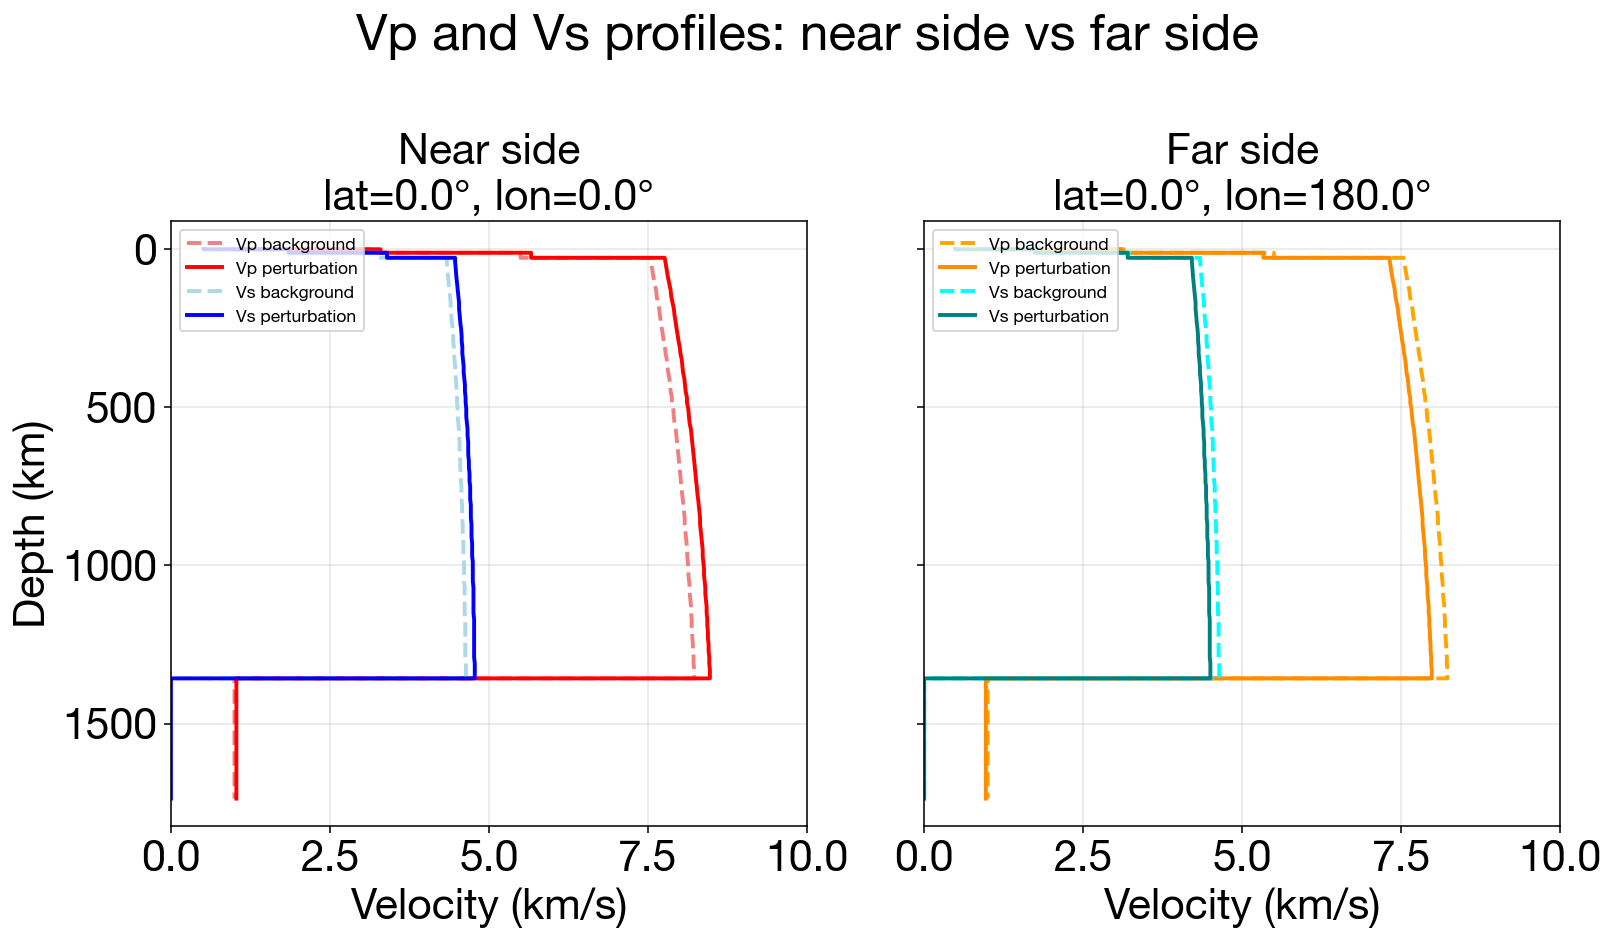

In [24]:
import pandas as pd
import pandas as pd


def read_vpremoon_model(model_file):
    rows = []
    started = False

    with open(model_file, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()

            # find the actual table header
            if not started:
                if len(parts) >= 4 and parts[0].lower() == "depth_km":
                    started = True
                continue

            # keep numeric rows only
            if len(parts) >= 4:
                try:
                    depth_km = float(parts[0])
                    vp_km_s = float(parts[1])
                    vs_km_s = float(parts[2])
                    rho_g_cm3 = float(parts[3])
                    rows.append([depth_km, vp_km_s, vs_km_s, rho_g_cm3])
                except ValueError:
                    continue

    if not rows:
        raise ValueError(f"No model rows found in file: {model_file}")

    df = pd.DataFrame(
        rows,
        columns=["depth_km", "vp_km_s", "vs_km_s", "rho_g_cm3"]
    )

    return df
def extract_local_profile_from_model_df(
    model_df,
    lat_deg,
    lon_deg,
    eps=None,
    kind=None,
    vector=None,
    perturb_density=False,
):
    """
    Apply a degree-1 perturbation field to a seismic model DataFrame
    and return the locally perturbed velocity profile.
    """

    global DEG1_VECTOR

    if eps is None:
        eps = DEG1_EPS
    if kind is None:
        kind = DEG1_KIND

    # Preserve original vector
    old_vec = DEG1_VECTOR.copy()

    if vector is not None:
        DEG1_VECTOR = np.asarray(vector, float)

    lat_rad = np.deg2rad(lat_deg)
    lon_rad = np.deg2rad(lon_deg)

    # Degree-1 field value at this location
    F0 = float(_deg1_field(lat_rad, lon_rad, kind=kind))

    # Scaling factor
    scale = 1.0 + eps * F0

    out = model_df.copy()

    out["field_value"] = F0
    out["scale"] = scale

    # Apply perturbation
    out["vp_local_km_s"] = out["vp_km_s"] * scale
    out["vs_local_km_s"] = out["vs_km_s"] * scale

    # Percent perturbations
    out["dvp_percent"] = 100.0 * (out["vp_local_km_s"] - out["vp_km_s"]) / out["vp_km_s"]
    out["dvs_percent"] = 100.0 * (out["vs_local_km_s"] - out["vs_km_s"]) / out["vs_km_s"]

    # Optional density perturbation
    if "density" in out.columns and perturb_density:
        out["density_local"] = out["density"] * scale
        out["drho_percent"] = (
            100.0 * (out["density_local"] - out["density"]) / out["density"]
        )

    # Restore original vector
    DEG1_VECTOR = old_vec

    return out
def plot_near_far_profiles(near_df, far_df, near_lat, near_lon, far_lat, far_lon):
    fig, axes = plt.subplots(1, 2, figsize=(12, 7), dpi=140, sharey=True)

    # Near side
    ax = axes[0]
    ax.plot(
        near_df["vp_km_s"], near_df["depth_km"],
        color="lightcoral", linestyle="--", linewidth=2,
        label="Vp background"
    )
    ax.plot(
        near_df["vp_local_km_s"], near_df["depth_km"],
        color="red", linestyle="-", linewidth=2,
        label="Vp perturbation"
    )
    ax.plot(
        near_df["vs_km_s"], near_df["depth_km"],
        color="lightblue", linestyle="--", linewidth=2,
        label="Vs background"
    )
    ax.plot(
        near_df["vs_local_km_s"], near_df["depth_km"],
        color="blue", linestyle="-", linewidth=2,
        label="Vs perturbation"
    )
    ax.set_title(f"Near side\nlat={near_lat:.1f}°, lon={near_lon:.1f}°")
    ax.set_xlabel("Velocity (km/s)")
    ax.set_ylabel("Depth (km)")
    ax.grid(alpha=0.3)
    ax.legend()

    # Far side
    ax = axes[1]
    ax.plot(
        far_df["vp_km_s"], far_df["depth_km"],
        color="orange", linestyle="--", linewidth=2,
        label="Vp background"
    )
    ax.plot(
        far_df["vp_local_km_s"], far_df["depth_km"],
        color="darkorange", linestyle="-", linewidth=2,
        label="Vp perturbation"
    )
    ax.plot(
        far_df["vs_km_s"], far_df["depth_km"],
        color="cyan", linestyle="--", linewidth=2,
        label="Vs background"
    )
    ax.plot(
        far_df["vs_local_km_s"], far_df["depth_km"],
        color="teal", linestyle="-", linewidth=2,
        label="Vs perturbation"
    )
    ax.set_title(f"Far side\nlat={far_lat:.1f}°, lon={far_lon:.1f}°")
    ax.set_xlabel("Velocity (km/s)")
    ax.grid(alpha=0.3)


    # Invert shared depth axis once
    axes[0].invert_yaxis()
    axes[0].legend(loc="upper left", fontsize=9)
    axes[1].legend(loc="upper left", fontsize=9)
    axes[0].set_xlim(0, 10)
    axes[1].set_xlim(0, 10)

    fig.suptitle("Vp and Vs profiles: near side vs far side", y=0.98)
    plt.tight_layout()
    plt.show()

def extract_local_profile_from_file(
    model_file,
    lat_deg,
    lon_deg,
    eps=None,
    kind=None,
    vector=None,
    perturb_density=False,
):
    model_df = read_vpremoon_model(model_file)
    return extract_local_profile_from_model_df(
        model_df=model_df,
        lat_deg=lat_deg,
        lon_deg=lon_deg,
        eps=eps,
        kind=kind,
        vector=vector,
        perturb_density=perturb_density,
    )


# ------------------------------------------------------------
# Define locations
# ------------------------------------------------------------
near_lat = 0.0
near_lon = 0.0        # near side

far_lat  = 0.0
far_lon  = 180.0      # far side

# ------------------------------------------------------------
# Compute profiles
# ------------------------------------------------------------
model_file = "/Users/ramonmargarit/Desktop/vpremoon_mantle_closed.tvel"

lat0 = 0.0
near_lon = 0.0      # near side
far_lon  = 180.0    # far side

near_df = extract_local_profile_from_file(
    model_file=model_file,
    lat_deg=lat0,
    lon_deg=near_lon,
    eps=DEG1_EPS,
    kind=DEG1_KIND,
    vector=DEG1_VECTOR,
    perturb_density=False,
)

far_df = extract_local_profile_from_file(
    model_file=model_file,
    lat_deg=lat0,
    lon_deg=far_lon,
    eps=DEG1_EPS,
    kind=DEG1_KIND,
    vector=DEG1_VECTOR,
    perturb_density=False,
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plot_near_far_profiles(
    near_df=near_df,
    far_df=far_df,
    near_lat=near_lat,
    near_lon=near_lon,
    far_lat=far_lat,
    far_lon=far_lon)